#  Unified Thermal Emitter Simulation

This notebook combines both **narrowband** (cubic structures) and **wideband** (cylindrical structures) thermal emitter simulations with optimized configurations for cost reduction.

## Key Features:
- **Unified codebase** - No repeated functions
- **Geometry selection** - Choose cubic (narrowband) or cylindrical (wideband) structures
- **Optimization built-in** - ~40-50% cost reduction compared to original
- **Blackbody physics** - Proper thermal emission at T=650K

## Optimizations Applied:
1. **Domain Size Reduction** (~39%): Structure positioned near bottom
2. **Source Count Reduction** (30%): 1000 → 700 dipole sources
3. **Grid Optimization**: Wavelength 0.2 → 0.35
4. **PML Layer Reduction** (33%): 30 → 20 layers

In [1]:
# Standard python imports
import numpy as np
import matplotlib.pyplot as plt
import tidy3d as td
from tidy3d import web
import random
from scipy.ndimage import gaussian_filter1d
import xarray as xr
from scipy.constants import h, c, k
from scipy.interpolate import interp1d

## Configuration settings

Select the simulation type and parameters below:

In [2]:
# ===== SIMULATION CONFIGURATION =====
GEOMETRY_TYPE = "cubic"  # Choose: "cubic" (narrowband) or "cylindrical" (wideband)
USE_OPTIMIZATION = True  # True for optimized (cheaper), False for original

# Simulation parameters
num_sims = 10
freq_samples = 20000
T = 650  # Temperature in Kelvin

# Material constraints
lambda_min = 2
lambda_max = 8
constraint_min = td.constants.C_0 / lambda_max
constraint_max = td.constants.C_0 / lambda_min

# Geometric parameters (micrometers)
if GEOMETRY_TYPE == "cubic":  # Narrowband parameters
    h1, h2, h3, h4 = 200e-3, 250e-3, 25e-3, 100e-3
    p, w = 3500e-3, 2700e-3
    geometry_name = "Narrowband (Cubic Structures)"
else:  # Wideband parameters
    h1, h2, h3, h4 = 200e-3, 250e-3, 25e-3, 150e-3
    p, w = 3000e-3, 1500e-3
    geometry_name = "Wideband (Cylindrical Structures)"

params = (h1, h2, h3, h4, p, w)
Lx, Ly, Lz = (p, p, 13)
monitor_distances = [1, 3, 8]

# Monitor specifications
monitor_freqs = np.linspace(constraint_min, constraint_max, 200)
monitor_wvls = td.constants.C_0 / monitor_freqs

print(f"Configuration: {geometry_name}")
print(f"Optimization: {'Enabled' if USE_OPTIMIZATION else 'Disabled'}")
print(f"Temperature: {T}K")
print(f"Structure size: {w*1000:.0f} nm")
print(f"Domain size: {p:.1f} × {p:.1f} × {Lz:.1f} μm")

Configuration: Narrowband (Cubic Structures)
Optimization: Enabled
Temperature: 650K
Structure size: 2700 nm
Domain size: 3.5 × 3.5 × 13.0 μm


## Blackbody frequency sampling

Generate frequencies according to Planck's blackbody spectrum:

In [3]:
def sample_blackbody_frequencies(T, N, nu_min, nu_max, nu_steps=10000000):
    """
    Sample frequencies from blackbody spectrum using inverse CDF method.

    Parameters:
    - T: Temperature (K)
    - N: Number of samples
    - nu_min, nu_max: Frequency range (Hz)
    - nu_steps: Resolution for CDF calculation
    """
    # Frequency peak ν_peak ≈ 2.821439 kT / h
    nu_peak = 2.821439 * k * T / h

    # Set integration bounds
    if nu_min is None:
        nu_min = 0.0
    if nu_max is None:
        nu_max = 10 * nu_peak

    # Frequency grid
    nu = np.linspace(nu_min, nu_max, nu_steps)[1:]  # avoid zero

    # Planck spectral radiance B(ν,T) ∝ ν³ / (exp(hν/kT) - 1)
    x = h * nu / (k * T)
    B = (2 * h * nu**3 / c**2) / (np.expm1(x))

    # Build PDF: normalize B over nu
    pdf = B / np.trapezoid(B, nu)

    # Build CDF
    cdf = np.cumsum(pdf)
    cdf /= cdf[-1]

    # Inverse CDF interpolator with bounds handling
    inv_cdf = interp1d(cdf, nu, bounds_error=False, fill_value=(nu[0], nu[-1]))

    # Draw uniform samples and map through inv CDF
    u = np.random.rand(N)
    samples = inv_cdf(u)

    return samples


# Generate frequency spectrum
freqs = sample_blackbody_frequencies(T, freq_samples, constraint_min, constraint_max)
freq0_peak = 2.821439 * k * T / h

print(f"Frequency range: {constraint_min:.2e} - {constraint_max:.2e} Hz")
print(f"Blackbody peak: {freq0_peak:.2e} Hz")
print(f"Generated range: {min(freqs):.2e} - {max(freqs):.2e} Hz")

Frequency range: 3.75e+13 - 1.50e+14 Hz
Blackbody peak: 3.82e+13 Hz
Generated range: 3.75e+13 - 1.50e+14 Hz


## Spectrum visualization

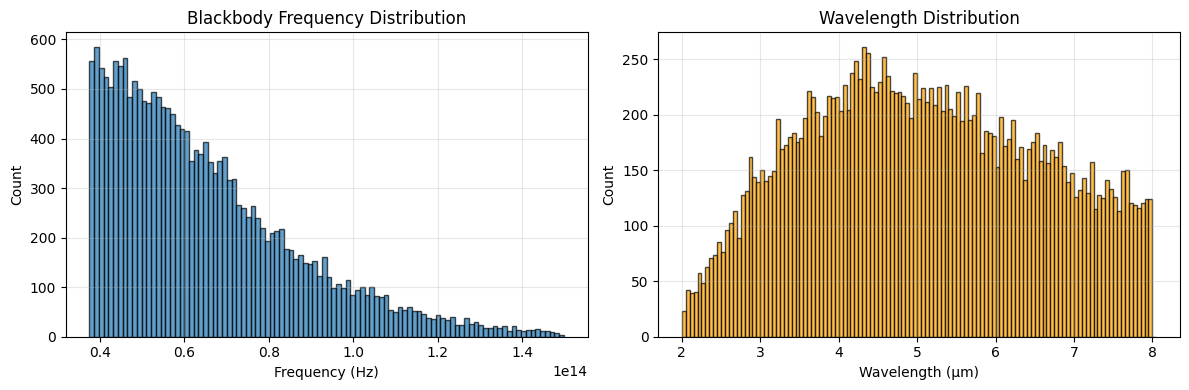

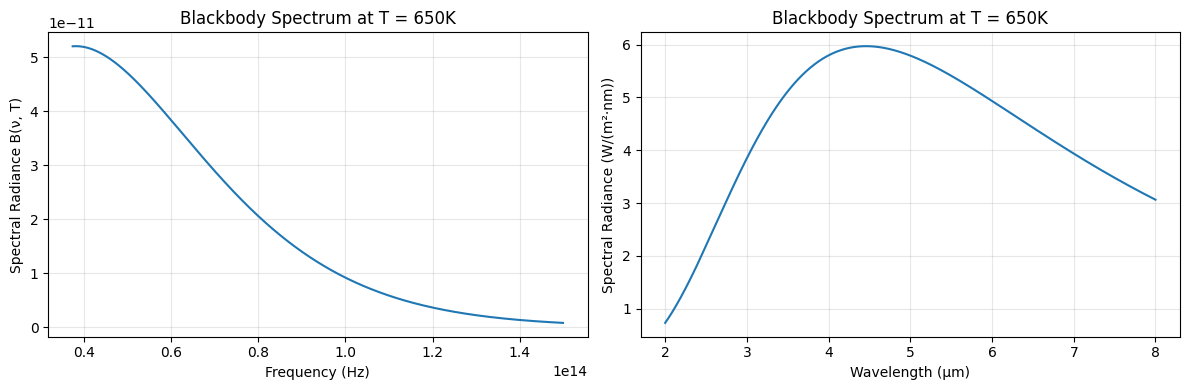

In [4]:
# Plot frequency distribution
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Frequency histogram
bin_width = 0.01 * (constraint_max - constraint_min)
bins = np.arange(constraint_min, constraint_max + bin_width, bin_width)
ax1.hist(freqs, bins=bins, edgecolor="black", alpha=0.7)
ax1.set_xlabel("Frequency (Hz)")
ax1.set_ylabel("Count")
ax1.set_title("Blackbody Frequency Distribution")
ax1.grid(True, alpha=0.3)

# Wavelength histogram
wavelengths_test = td.constants.C_0 / freqs
bin_width = 0.05
bins = np.arange(lambda_min, lambda_max + bin_width, bin_width)
ax2.hist(wavelengths_test, bins=bins, edgecolor="black", alpha=0.7, color="orange")
ax2.set_xlabel("Wavelength (μm)")
ax2.set_ylabel("Count")
ax2.set_title("Wavelength Distribution")
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Blackbody spectrum comparison
nu_theory = np.linspace(constraint_min, constraint_max, 1000)
lambdas = (td.constants.C_0 / nu_theory) * 1e-6  # m

# Theoretical blackbody spectra
B_nu = (2 * h * nu_theory**3 / c**2) / (np.exp(h * nu_theory / (k * T)) - 1)
B_lambda = (2 * h * c**2 / lambdas**5) / (np.exp(h * c / (lambdas * k * T)) - 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(nu_theory, B_nu)
ax1.set_xlabel("Frequency (Hz)")
ax1.set_ylabel("Spectral Radiance B(ν, T)")
ax1.set_title(f"Blackbody Spectrum at T = {T}K")
ax1.grid(True, alpha=0.3)

ax2.plot(lambdas * 1e6, 4 * np.pi * B_lambda * 1e-9)
ax2.set_xlabel("Wavelength (μm)")
ax2.set_ylabel(f"Spectral Radiance (W/(m²·nm))")
ax2.set_title(f"Blackbody Spectrum at T = {T}K")
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Unified source generation

Generates dipole sources for both cubic and cylindrical geometries:

In [5]:
def dipole_source_unified(num_source, freqs, params, geometry_type="cubic", z_offset=0):
    """
    Generate dipole sources for thermal fluctuations.

    Parameters:
    - num_source: Total number of sources
    - freqs: Frequency samples from blackbody distribution
    - params: Geometric parameters (h1, h2, h3, h4, p, w)
    - geometry_type: "cubic" or "cylindrical"
    - z_offset: Vertical offset for optimization
    """
    h1, h2, h3, h4, p, w = params

    # Volume calculations
    V_substrate = (h1 + h2) * p * p

    if geometry_type == "cubic":
        V_structure = 5 * (h3 + h4) * w * w
    else:  # cylindrical
        V_structure = 5 * (h3 + h4) * np.pi * (w / 2) ** 2

    num_source_structure = int((V_structure / V_substrate) * num_source)
    num_source_substrate = num_source - num_source_structure

    sources = []
    locs = []

    # Substrate sources
    for i in range(num_source_substrate):
        f = np.random.choice(freqs)
        pulse = td.GaussianPulse(
            freq0=f,
            fwidth=0.1 * (constraint_max - constraint_min),
            phase=np.random.uniform(0, 2 * np.pi),
        )

        x_coord = np.random.uniform(-p / 2, p / 2)
        y_coord = np.random.uniform(-p / 2, p / 2)
        z_coord = np.random.uniform(z_offset, z_offset + (h1 + h2))

        polarizations = ["Ex", "Ey", "Ez", "Hx", "Hy", "Hz"]
        rand_pol = random.choice(polarizations)

        pt_dipole = td.PointDipole(
            center=(x_coord, y_coord, z_coord),
            source_time=pulse,
            polarization=rand_pol,
            interpolate=True,
        )
        sources.append(pt_dipole)
        locs.append((x_coord, y_coord, z_coord))

    # Structure sources (cubic or cylindrical)
    for i in range(num_source_structure):
        f = np.random.choice(freqs)
        pulse = td.GaussianPulse(
            freq0=f,
            fwidth=0.1 * (constraint_max - constraint_min),
            phase=np.random.uniform(0, 2 * np.pi),
        )

        if geometry_type == "cubic":
            # Cubic structure sources
            x_coord = np.random.uniform(-w / 2, w / 2)
            y_coord = np.random.uniform(-w / 2, w / 2)
        else:
            # Cylindrical structure sources
            theta = np.random.uniform(0, 2 * np.pi)
            r = (w / 2) * np.sqrt(np.random.uniform(0, 1))
            x_coord = r * np.cos(theta)
            y_coord = r * np.sin(theta)

        z_coord = np.random.uniform(
            z_offset + (h1 + h2), z_offset + (h1 + h2) + 5 * (h3 + h4)
        )

        polarizations = ["Ex", "Ey", "Ez", "Hx", "Hy", "Hz"]
        rand_pol = random.choice(polarizations)

        pt_dipole = td.PointDipole(
            center=(x_coord, y_coord, z_coord),
            source_time=pulse,
            polarization=rand_pol,
            interpolate=True,
        )
        sources.append(pt_dipole)
        locs.append((x_coord, y_coord, z_coord))

    return sources, locs

## Unified structure creation

In [6]:
def make_structure_unified(num_pairs, params, geometry_type="cubic", z_offset=0):
    """
    Create structure stack with cubic or cylindrical geometry.

    Parameters:
    - num_pairs: Number of structure layer pairs
    - params: Geometric parameters (h1, h2, h3, h4, p, w)
    - geometry_type: "cubic" or "cylindrical"
    - z_offset: Vertical offset for optimization
    """
    h1, h2, h3, h4, p, w = params

    # Materials
    Ni = td.PoleResidue.from_file("Ni_0_12.json")
    SiO2 = td.Medium(permittivity=2.08, name="SiO2")

    # Layer specifications
    layers = [
        ("substrate_Ni", h1, Ni, (td.inf, td.inf)),
        ("spacer_SiO2", h2, SiO2, (td.inf, td.inf)),
    ]

    for i in range(1, num_pairs + 1):
        layers.append((f"structure_Ni_{i}", h3, Ni, (w, w)))
        layers.append((f"structure_SiO2_{i}", h4, SiO2, (w, w)))

    # Build structure stack
    stack = []
    z_current = z_offset

    for name, thickness, medium, (sx, sy) in layers:
        z_center = z_current + thickness / 2

        if "substrate" in name or "spacer" in name:
            # Substrate and spacer layers (always boxes)
            geometry = td.Box(center=(0, 0, z_center), size=(sx, sy, thickness))
        else:
            # Structure layers (cubic or cylindrical)
            if geometry_type == "cubic":
                geometry = td.Box(center=(0, 0, z_center), size=(sx, sy, thickness))
            else:  # cylindrical
                geometry = td.Cylinder(
                    center=(0, 0, z_center), radius=w / 2, length=thickness, axis=2
                )

        stack.append(td.Structure(geometry=geometry, medium=medium, name=name))
        z_current += thickness

    return stack


def create_monitors_unified(monitor_distances, params, z_offset=0):
    """
    Create monitors that follow structure positioning.
    """
    h1, h2, h3, h4, p, w = params
    structure_top = z_offset + h1 + h2 + 5 * (h3 + h4)

    monitors = []
    for distance in monitor_distances:
        monitor = td.FluxMonitor(
            center=(0, 0, structure_top + distance),
            size=(Lx, Ly, 0),
            freqs=monitor_freqs,
            name=f"monitor_{distance}",
        )
        monitors.append(monitor)
    return monitors

## Unified simulation creation

In [7]:
def make_simulation_unified(T, geometry_type="cubic", optimized=True):
    """
    Create thermal emitter simulation with unified parameters.

    Parameters:
    - T: Temperature (K)
    - geometry_type: "cubic" or "cylindrical"
    - optimized: True for optimized version, False for original
    """
    # Fixed physics parameters
    run_time = 10e-13

    if optimized:
        # Optimized parameters for cost reduction
        sim_size_z = 4  # Compact domain
        grid_wavelength = 0.35  # Coarser grid
        num_sources = 700  # Fewer sources
        pml_layers = 20  # Fewer PML layers
        z_offset = -4  # Structure positioning offset
        sim_label = "Optimized"
    else:
        # Original parameters
        sim_size_z = lambda_max  # Larger domain
        grid_wavelength = 0.2  # Finer grid
        num_sources = 1000  # More sources
        pml_layers = 30  # More PML layers
        z_offset = 0  # No offset
        sim_label = "Original"

    sim_size = (Lx, Ly, Lz + sim_size_z)
    grid_spec = td.GridSpec.auto(wavelength=grid_wavelength)

    # Generate blackbody frequency spectrum
    freqs = sample_blackbody_frequencies(
        T, freq_samples, constraint_min, constraint_max
    )

    # Create components
    stack = make_structure_unified(5, params, geometry_type, z_offset)
    sources, locs = dipole_source_unified(
        num_sources, freqs, params, geometry_type, z_offset
    )
    monitors = create_monitors_unified(monitor_distances, params, z_offset)

    # Boundary conditions
    boundary_spec = td.BoundarySpec(
        x=td.Boundary(minus=td.Periodic(), plus=td.Periodic()),
        y=td.Boundary(minus=td.Periodic(), plus=td.Periodic()),
        z=td.Boundary(
            minus=td.PML(num_layers=pml_layers), plus=td.PML(num_layers=pml_layers)
        ),
    )

    # Create simulation
    sim = td.Simulation(
        center=(0, 0, 0),
        size=sim_size,
        grid_spec=grid_spec,
        structures=stack,
        sources=sources,
        monitors=monitors,
        run_time=run_time,
        boundary_spec=boundary_spec,
        normalize_index=None,
    )

    print(f"{geometry_name} {sim_label} simulation created.")
    print(f"Sources: {len(sources)}, Grid: λ/{grid_wavelength:.2f}, PML: {pml_layers}")
    print(f"Domain: {sim_size[0]:.1f}×{sim_size[1]:.1f}×{sim_size[2]:.1f} μm")

    return sim

## Experimental Section


In [8]:
def dipole_source_uniform_freq(num_source, params, geometry_type="cubic", z_offset=0):
    """
    Generate dipole sources with uniformly distributed frequencies.

    Parameters:
    - num_source: Total number of sources
    - params: Geometric parameters (h1, h2, h3, h4, p, w)
    - geometry_type: "cubic" or "cylindrical"
    - z_offset: Vertical offset for optimization
    """
    h1, h2, h3, h4, p, w = params

    # Volume calculations (same as before)
    V_substrate = (h1 + h2) * p * p
    if geometry_type == "cubic":
        V_structure = 5 * (h3 + h4) * w * w
    else:  # cylindrical
        V_structure = 5 * (h3 + h4) * np.pi * (w / 2) ** 2

    num_source_structure = int((V_structure / V_substrate) * num_source)
    num_source_substrate = num_source - num_source_structure

    sources = []
    locs = []

    # Generate uniform frequency distribution
    freqs_uniform = np.random.uniform(constraint_min, constraint_max, num_source)

    # Substrate sources
    for i in range(num_source_substrate):
        f = freqs_uniform[i]  # Use uniform frequency
        pulse = td.GaussianPulse(
            freq0=f,
            fwidth=0.1 * (constraint_max - constraint_min),
            phase=np.random.uniform(0, 2 * np.pi),
        )

        x_coord = np.random.uniform(-p / 2, p / 2)
        y_coord = np.random.uniform(-p / 2, p / 2)
        z_coord = np.random.uniform(z_offset, z_offset + (h1 + h2))

        polarizations = ["Ex", "Ey", "Ez", "Hx", "Hy", "Hz"]
        rand_pol = random.choice(polarizations)

        pt_dipole = td.PointDipole(
            center=(x_coord, y_coord, z_coord),
            source_time=pulse,
            polarization=rand_pol,
            interpolate=True,
        )
        sources.append(pt_dipole)
        locs.append((x_coord, y_coord, z_coord))

    # Structure sources
    for i in range(num_source_structure):
        f = freqs_uniform[num_source_substrate + i]  # Continue uniform sequence
        pulse = td.GaussianPulse(
            freq0=f,
            fwidth=0.1 * (constraint_max - constraint_min),
            phase=np.random.uniform(0, 2 * np.pi),
        )

        if geometry_type == "cubic":
            x_coord = np.random.uniform(-w / 2, w / 2)
            y_coord = np.random.uniform(-w / 2, w / 2)
        else:
            theta = np.random.uniform(0, 2 * np.pi)
            r = (w / 2) * np.sqrt(np.random.uniform(0, 1))
            x_coord = r * np.cos(theta)
            y_coord = r * np.sin(theta)

        z_coord = np.random.uniform(
            z_offset + (h1 + h2), z_offset + (h1 + h2) + 5 * (h3 + h4)
        )

        polarizations = ["Ex", "Ey", "Ez", "Hx", "Hy", "Hz"]
        rand_pol = random.choice(polarizations)

        pt_dipole = td.PointDipole(
            center=(x_coord, y_coord, z_coord),
            source_time=pulse,
            polarization=rand_pol,
            interpolate=True,
        )
        sources.append(pt_dipole)
        locs.append((x_coord, y_coord, z_coord))

    return sources, locs, freqs_uniform


def dipole_source_single_freq(
    num_source, params, geometry_type="cubic", z_offset=0, freq_width_factor=0.5
):
    """
    Generate dipole sources with same central frequency and large frequency width.

    Parameters:
    - num_source: Total number of sources
    - params: Geometric parameters (h1, h2, h3, h4, p, w)
    - geometry_type: "cubic" or "cylindrical"
    - z_offset: Vertical offset for optimization
    - freq_width_factor: Fraction of total bandwidth for frequency width
    """
    h1, h2, h3, h4, p, w = params

    # Volume calculations
    V_substrate = (h1 + h2) * p * p
    if geometry_type == "cubic":
        V_structure = 5 * (h3 + h4) * w * w
    else:
        V_structure = 5 * (h3 + h4) * np.pi * (w / 2) ** 2

    num_source_structure = int((V_structure / V_substrate) * num_source)
    num_source_substrate = num_source - num_source_structure

    sources = []
    locs = []

    # Single central frequency for all dipoles
    freq_center = (constraint_min + constraint_max) / 2  # Middle of range
    freq_width = freq_width_factor * (constraint_max - constraint_min)  # Large width

    print(
        f"Using single frequency: {freq_center:.2e} Hz with width: {freq_width:.2e} Hz"
    )

    # Substrate sources
    for i in range(num_source_substrate):
        pulse = td.GaussianPulse(
            freq0=freq_center,
            fwidth=freq_width,  # Large frequency width
            phase=np.random.uniform(0, 2 * np.pi),
        )

        x_coord = np.random.uniform(-p / 2, p / 2)
        y_coord = np.random.uniform(-p / 2, p / 2)
        z_coord = np.random.uniform(z_offset, z_offset + (h1 + h2))

        polarizations = ["Ex", "Ey", "Ez", "Hx", "Hy", "Hz"]
        rand_pol = random.choice(polarizations)

        pt_dipole = td.PointDipole(
            center=(x_coord, y_coord, z_coord),
            source_time=pulse,
            polarization=rand_pol,
            interpolate=True,
        )
        sources.append(pt_dipole)
        locs.append((x_coord, y_coord, z_coord))

    # Structure sources
    for i in range(num_source_structure):
        pulse = td.GaussianPulse(
            freq0=freq_center,
            fwidth=freq_width,  # Same large width
            phase=np.random.uniform(0, 2 * np.pi),
        )

        if geometry_type == "cubic":
            x_coord = np.random.uniform(-w / 2, w / 2)
            y_coord = np.random.uniform(-w / 2, w / 2)
        else:
            theta = np.random.uniform(0, 2 * np.pi)
            r = (w / 2) * np.sqrt(np.random.uniform(0, 1))
            x_coord = r * np.cos(theta)
            y_coord = r * np.sin(theta)

        z_coord = np.random.uniform(
            z_offset + (h1 + h2), z_offset + (h1 + h2) + 5 * (h3 + h4)
        )

        polarizations = ["Ex", "Ey", "Ez", "Hx", "Hy", "Hz"]
        rand_pol = random.choice(polarizations)

        pt_dipole = td.PointDipole(
            center=(x_coord, y_coord, z_coord),
            source_time=pulse,
            polarization=rand_pol,
            interpolate=True,
        )
        sources.append(pt_dipole)
        locs.append((x_coord, y_coord, z_coord))

    return sources, locs


def dipole_source_layer_distributed(
    num_source, params, geometry_type="cubic", z_offset=0, layer_distribution="equal"
):
    """
    Generate dipole sources distributed by layer.

    Parameters:
    - num_source: Total number of sources
    - params: Geometric parameters (h1, h2, h3, h4, p, w)
    - geometry_type: "cubic" or "cylindrical"
    - z_offset: Vertical offset for optimization
    - layer_distribution: "equal", "volume_weighted", or "surface_heavy"
    """
    h1, h2, h3, h4, p, w = params
    freqs = sample_blackbody_frequencies(
        T, freq_samples, constraint_min, constraint_max
    )

    sources = []
    locs = []

    # Define layer boundaries
    layers_info = [
        ("substrate", z_offset, z_offset + h1, p, p),
        ("spacer", z_offset + h1, z_offset + h1 + h2, p, p),
    ]

    # Add structure layers
    z_current = z_offset + h1 + h2
    for i in range(5):  # 5 pairs
        layers_info.append((f"structure_Ni_{i+1}", z_current, z_current + h3, w, w))
        z_current += h3
        layers_info.append((f"structure_SiO2_{i+1}", z_current, z_current + h4, w, w))
        z_current += h4

    # Calculate source distribution
    if layer_distribution == "equal":
        # equal distribution of sources
        sources_per_layer = [num_source // len(layers_info)] * len(layers_info)
        sources_per_layer[0] += num_source % len(
            layers_info
        )  # Add remainder to first layer
    elif layer_distribution == "volume_weighted":
        # Volume-weighted distribution of sources (layer with more volume gets more sources)
        volumes = []
        for name, z_min, z_max, sx, sy in layers_info:
            if geometry_type == "cubic" or "substrate" in name or "spacer" in name:
                vol = (z_max - z_min) * sx * sy
            else:  # cylindrical structure layers
                vol = (z_max - z_min) * np.pi * (sx / 2) ** 2
            volumes.append(vol)
        total_vol = sum(volumes)
        sources_per_layer = [int(num_source * vol / total_vol) for vol in volumes]
    elif layer_distribution == "surface_heavy":
        # More sources at interfaces / surfaces
        sources_per_layer = [50, 50]  # substrate, spacer
        remaining = num_source - 100
        structure_sources = remaining // 10  # 10 structure layers
        sources_per_layer.extend([structure_sources] * 10)
        sources_per_layer[0] += remaining % 10

    print(f"Layer distribution ({layer_distribution}):")
    for i, (layer_info, n_sources) in enumerate(zip(layers_info, sources_per_layer)):
        print(f"  {layer_info[0]}: {n_sources} sources")

    # Generate sources for each layer
    for (name, z_min, z_max, sx, sy), n_sources in zip(layers_info, sources_per_layer):
        for i in range(n_sources):
            f = np.random.choice(freqs)
            pulse = td.GaussianPulse(
                freq0=f,
                fwidth=0.1 * (constraint_max - constraint_min),
                phase=np.random.uniform(0, 2 * np.pi),
            )

            # Position within layer
            if geometry_type == "cubic" or "substrate" in name or "spacer" in name:
                x_coord = np.random.uniform(-sx / 2, sx / 2)
                y_coord = np.random.uniform(-sy / 2, sy / 2)
            else:  # cylindrical structure layers
                theta = np.random.uniform(0, 2 * np.pi)
                r = (sx / 2) * np.sqrt(np.random.uniform(0, 1))
                x_coord = r * np.cos(theta)
                y_coord = r * np.sin(theta)

            z_coord = np.random.uniform(z_min, z_max)

            polarizations = ["Ex", "Ey", "Ez", "Hx", "Hy", "Hz"]
            rand_pol = random.choice(polarizations)

            pt_dipole = td.PointDipole(
                center=(x_coord, y_coord, z_coord),
                source_time=pulse,
                polarization=rand_pol,
                interpolate=True,
            )
            sources.append(pt_dipole)
            locs.append((x_coord, y_coord, z_coord))

    return sources, locs


def dipole_source_surface_only(
    num_source, params, geometry_type="cubic", z_offset=0, surface_thickness=0.05
):
    """
    Generate dipole sources only at surfaces/interfaces.

    Parameters:
    - num_source: Total number of sources
    - params: Geometric parameters (h1, h2, h3, h4, p, w)
    - geometry_type: "cubic" or "cylindrical"
    - z_offset: Vertical offset for optimization
    - surface_thickness: Thickness of surface layer (μm)
    """
    h1, h2, h3, h4, p, w = params
    freqs = sample_blackbody_frequencies(
        T, freq_samples, constraint_min, constraint_max
    )

    sources = []
    locs = []

    # Define surface regions (top and bottom of each layer)
    surfaces = [
        # Substrate surfaces
        (
            "substrate_top",
            z_offset + h1 - surface_thickness / 2,
            z_offset + h1 + surface_thickness / 2,
            p,
            p,
        ),
        # Spacer surfaces
        (
            "spacer_bottom",
            z_offset + h1 - surface_thickness / 2,
            z_offset + h1 + surface_thickness / 2,
            p,
            p,
        ),
        (
            "spacer_top",
            z_offset + h1 + h2 - surface_thickness / 2,
            z_offset + h1 + h2 + surface_thickness / 2,
            p,
            p,
        ),
    ]

    # Add structure layer surfaces
    z_current = z_offset + h1 + h2
    for i in range(5):
        # Ni layer surfaces
        surfaces.append(
            (
                f"Ni_{i+1}_bottom",
                z_current - surface_thickness / 2,
                z_current + surface_thickness / 2,
                w,
                w,
            )
        )
        z_current += h3
        surfaces.append(
            (
                f"Ni_{i+1}_top",
                z_current - surface_thickness / 2,
                z_current + surface_thickness / 2,
                w,
                w,
            )
        )

        # SiO2 layer surfaces
        surfaces.append(
            (
                f"SiO2_{i+1}_bottom",
                z_current - surface_thickness / 2,
                z_current + surface_thickness / 2,
                w,
                w,
            )
        )
        z_current += h4
        surfaces.append(
            (
                f"SiO2_{i+1}_top",
                z_current - surface_thickness / 2,
                z_current + surface_thickness / 2,
                w,
                w,
            )
        )

    sources_per_surface = num_source // len(surfaces)
    remainder = num_source % len(surfaces)

    print(f"Surface-only distribution:")
    print(f"  {len(surfaces)} surfaces with {sources_per_surface} sources each")
    print(f"  Surface thickness: {surface_thickness} μm")

    # Generate sources at each surface
    for i, (name, z_min, z_max, sx, sy) in enumerate(surfaces):
        n_sources = sources_per_surface + (1 if i < remainder else 0)

        for j in range(n_sources):
            f = np.random.choice(freqs)
            pulse = td.GaussianPulse(
                freq0=f,
                fwidth=0.1 * (constraint_max - constraint_min),
                phase=np.random.uniform(0, 2 * np.pi),
            )

            # Position at surface
            if geometry_type == "cubic" or "substrate" in name or "spacer" in name:
                x_coord = np.random.uniform(-sx / 2, sx / 2)
                y_coord = np.random.uniform(-sy / 2, sy / 2)
            else:  # cylindrical structure surfaces
                theta = np.random.uniform(0, 2 * np.pi)
                r = (sx / 2) * np.sqrt(np.random.uniform(0, 1))
                x_coord = r * np.cos(theta)
                y_coord = r * np.sin(theta)

            z_coord = np.random.uniform(z_min, z_max)

            polarizations = ["Ex", "Ey", "Ez", "Hx", "Hy", "Hz"]
            rand_pol = random.choice(polarizations)

            pt_dipole = td.PointDipole(
                center=(x_coord, y_coord, z_coord),
                source_time=pulse,
                polarization=rand_pol,
                interpolate=True,
            )
            sources.append(pt_dipole)
            locs.append((x_coord, y_coord, z_coord))

    return sources, locs

In [9]:
def make_experimental_simulation(
    T, geometry_type="cubic", optimized=True, experiment_type="blackbody"
):
    """
    Create experimental simulation with different source configurations.

    Parameters:
    - T: Temperature (K)
    - geometry_type: "cubic" or "cylindrical"
    - optimized: True for optimized version, False for original
    - experiment_type: "blackbody", "uniform_freq", "single_freq", "layer_equal",
                      "layer_volume", "layer_surface", "surface_only"
    """
    # Same optimization parameters as before
    run_time = 10e-13

    if optimized:
        sim_size_z = 4
        grid_wavelength = 0.35
        num_sources = 700
        pml_layers = 20
        z_offset = -4
        sim_label = f"Optimized-{experiment_type}"
    else:
        sim_size_z = lambda_max
        grid_wavelength = 0.2
        num_sources = 1000
        pml_layers = 30
        z_offset = 0
        sim_label = f"Original-{experiment_type}"

    sim_size = (Lx, Ly, Lz + sim_size_z)
    grid_spec = td.GridSpec.auto(wavelength=grid_wavelength)

    # Create structure (same as before)
    stack = make_structure_unified(5, params, geometry_type, z_offset)
    monitors = create_monitors_unified(monitor_distances, params, z_offset)

    # Choose source generation based on experiment type
    if experiment_type == "blackbody":
        freqs = sample_blackbody_frequencies(
            T, freq_samples, constraint_min, constraint_max
        )
        sources, locs = dipole_source_unified(
            num_sources, freqs, params, geometry_type, z_offset
        )
    elif experiment_type == "uniform_freq":
        # Uniform frequency distribution
        sources, locs, freqs_used = dipole_source_uniform_freq(
            num_sources, params, geometry_type, z_offset
        )
    elif experiment_type == "single_freq":
        # Single frequency distribution with large frequency width
        sources, locs = dipole_source_single_freq(
            num_sources, params, geometry_type, z_offset, freq_width_factor=0.5
        )
    elif experiment_type == "layer_equal":
        # Equal distribution of sources
        sources, locs = dipole_source_layer_distributed(
            num_sources, params, geometry_type, z_offset, "equal"
        )
    elif experiment_type == "layer_volume":
        # Volume-weighted distribution of sources (layer with more volume gets more sources)
        sources, locs = dipole_source_layer_distributed(
            num_sources, params, geometry_type, z_offset, "volume_weighted"
        )
    elif experiment_type == "layer_surface":
        # Surface-heavy distribution of sources (more sources at interfaces / surfaces)
        sources, locs = dipole_source_layer_distributed(
            num_sources, params, geometry_type, z_offset, "surface_heavy"
        )
    elif experiment_type == "surface_only":
        # Surface-only distribution of sources (only at the top surface)
        sources, locs = dipole_source_surface_only(
            num_sources, params, geometry_type, z_offset
        )
    else:
        raise ValueError(f"Unknown experiment type: {experiment_type}")

    # Boundary conditions
    boundary_spec = td.BoundarySpec(
        x=td.Boundary(minus=td.Periodic(), plus=td.Periodic()),
        y=td.Boundary(minus=td.Periodic(), plus=td.Periodic()),
        z=td.Boundary(
            minus=td.PML(num_layers=pml_layers), plus=td.PML(num_layers=pml_layers)
        ),
    )

    # Create simulation
    sim = td.Simulation(
        center=(0, 0, 0),
        size=sim_size,
        grid_spec=grid_spec,
        structures=stack,
        sources=sources,
        monitors=monitors,
        run_time=run_time,
        boundary_spec=boundary_spec,
        normalize_index=None,
    )

    return sim, sources, locs

#### Create Batch Simulation Function For Experiments

In [10]:
def run_experimental_batch_simulations():
    """Run batch simulations for all experimental configurations"""

    experiments = [
        "blackbody",  # Original blackbody distribution
        "uniform_freq",  # Uniform frequency distribution
        "single_freq",  # Single frequency with large width
        "layer_equal",  # Equal sources per layer
        "layer_volume",  # Volume-weighted layer distribution
        "surface_only",  # Sources only at surfaces
    ]

    experimental_results = {}
    experimental_costs = {}

    print("EXPERIMENTAL BATCH SIMULATIONS")
    print("=" * 60)

    for exp_type in experiments:
        print(f"\n🧪 Running {exp_type} experiment...")

        try:
            # Create batch simulations for this experiment type
            exp_sims = {}
            for i in range(1, num_sims + 1):
                exp_sims[f"sim_{i}"] = make_experimental_simulation(
                    T, GEOMETRY_TYPE, USE_OPTIMIZATION, exp_type
                )[
                    0
                ]  # Only need the simulation object

            # Estimate cost for one simulation
            job_exp = td.web.Job(
                simulation=exp_sims["sim_1"], task_name=f"{exp_type}_test"
            )
            cost_per_sim = td.web.estimate_cost(job_exp.task_id)
            total_cost = cost_per_sim * num_sims
            experimental_costs[exp_type] = {
                "per_sim": cost_per_sim,
                "total": total_cost,
            }

            print(f"   Cost per simulation: {cost_per_sim:.2f} credits")
            print(f"   Total cost: {total_cost:.2f} credits")

            # Run batch
            geometry_folder = "narrowband" if GEOMETRY_TYPE == "cubic" else "wideband"
            opt_folder = "_optimized" if USE_OPTIMIZATION else ""
            data_path = (
                f"data_{geometry_folder}{opt_folder}_experiments/{exp_type}_{T}K"
            )

            batch_exp = td.web.Batch(simulations=exp_sims, verbose=True)
            print(f"   Running {len(exp_sims)} simulations...")
            print(f"   Results will be saved to: {data_path}")

            batch_results_exp = batch_exp.run(path_dir=data_path)
            experimental_results[exp_type] = {
                "batch_results": batch_results_exp,
                "data_path": data_path,
                "cost": experimental_costs[exp_type],
            }

            print(f"   ✅ {exp_type} completed successfully!")

        except Exception as e:
            print(f"   ❌ {exp_type} failed: {str(e)}")
            experimental_results[exp_type] = None

    return experimental_results, experimental_costs

#### Analysis Function For Experimental Results

In [11]:
def analyze_experimental_results(experimental_results):
    """Analyze and process results from all experimental configurations"""

    experimental_data = {}

    print("\n📊 ANALYZING EXPERIMENTAL RESULTS")
    print("=" * 60)

    for exp_type, results in experimental_results.items():
        if results is None:
            print(f"❌ Skipping {exp_type} (failed)")
            continue

        print(f"\n📈 Processing {exp_type} results...")

        # Process results similar to your existing analysis
        data = []
        for task_name, sim_data in results["batch_results"].items():
            data.append(sim_data)

        # Analyze flux data at different monitor distances
        flux_data_distances = []
        power_density_data_distances_f = []
        power_density_data_distances_wvls = []

        for distance in monitor_distances:
            flux = xr.concat([d[f"monitor_{distance}"].flux for d in data], dim="sim")
            flux_data_summed = np.array(flux.sum(dim="sim"))  # W

            # Power density calculations
            area = (Lx * 1e-6) * (Ly * 1e-6)  # m²
            power_dens_f = flux_data_summed / (area * monitor_freqs)  # W/(m²Hz)
            power_dens_wvl = flux_data_summed / (
                area * (monitor_wvls * 1e3)
            )  # W/(m²nm)

            flux_data_distances.append(flux_data_summed)
            power_density_data_distances_f.append(power_dens_f)
            power_density_data_distances_wvls.append(power_dens_wvl)

        experimental_data[exp_type] = {
            "flux_data_distances": flux_data_distances,
            "power_density_data_distances_f": power_density_data_distances_f,
            "power_density_data_distances_wvls": power_density_data_distances_wvls,
            "data_path": results["data_path"],
            "cost": results["cost"],
        }

        print(f"   ✅ Analysis complete for {exp_type}")

    return experimental_data

#### Visulisation Function For All Experiments

In [12]:
def plot_experimental_comparison(experimental_data):
    """Create comparison plots for all experimental configurations"""

    print("\n📊 CREATING EXPERIMENTAL COMPARISON PLOTS")
    print("=" * 60)

    # Create a large comparison figure
    fig, axes = plt.subplots(3, 2, figsize=(20, 15))
    fig.suptitle(
        f"Experimental Source Distribution Comparison - {geometry_name}",
        fontsize=16,
        fontweight="bold",
    )

    # Colors for different experiments
    colors = plt.cm.tab10(np.linspace(0, 1, len(experimental_data)))
    experiment_colors = dict(zip(experimental_data.keys(), colors))

    # Plot 1: Frequency spectrum comparison (distance = 1μm)
    ax1 = axes[0, 0]
    for exp_type, data in experimental_data.items():
        ax1.plot(
            monitor_freqs,
            data["power_density_data_distances_f"][0],
            label=exp_type,
            color=experiment_colors[exp_type],
            linewidth=2,
        )
    ax1.set_xlabel("Frequency (Hz)")
    ax1.set_ylabel("Power Density (W/(m²Hz))")
    ax1.set_title("Frequency Spectrum (d=1μm)")
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    # Plot 2: Wavelength spectrum comparison (distance = 1μm)
    ax2 = axes[0, 1]
    for exp_type, data in experimental_data.items():
        ax2.plot(
            monitor_wvls,
            data["power_density_data_distances_wvls"][0],
            label=exp_type,
            color=experiment_colors[exp_type],
            linewidth=2,
        )
    ax2.set_xlabel("Wavelength (μm)")
    ax2.set_ylabel("Power Density (W/(m²nm))")
    ax2.set_title("Wavelength Spectrum (d=1μm)")
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    # Plot 3: Zoomed wavelength view (4-6 μm)
    ax3 = axes[1, 0]
    for exp_type, data in experimental_data.items():
        ax3.plot(
            monitor_wvls,
            data["power_density_data_distances_wvls"][0],
            label=exp_type,
            color=experiment_colors[exp_type],
            linewidth=2,
        )
    ax3.set_xlabel("Wavelength (μm)")
    ax3.set_ylabel("Power Density (W/(m²nm))")
    ax3.set_title("Wavelength Spectrum - Zoomed (d=1μm)")
    ax3.set_xlim(4, 6)
    ax3.legend()
    ax3.grid(True, alpha=0.3)

    # Plot 4: Peak power comparison across distances
    ax4 = axes[1, 1]
    distances_array = np.array(monitor_distances)
    for exp_type, data in experimental_data.items():
        peak_powers = [
            np.max(data["power_density_data_distances_wvls"][i])
            for i in range(len(monitor_distances))
        ]
        ax4.plot(
            distances_array,
            peak_powers,
            "o-",
            label=exp_type,
            color=experiment_colors[exp_type],
            linewidth=2,
            markersize=8,
        )
    ax4.set_xlabel("Monitor Distance (μm)")
    ax4.set_ylabel("Peak Power Density (W/(m²nm))")
    ax4.set_title("Peak Power vs Distance")
    ax4.legend()
    ax4.grid(True, alpha=0.3)

    # Plot 5: Peak wavelength comparison
    ax5 = axes[2, 0]
    exp_names = list(experimental_data.keys())
    peak_wavelengths = []
    for exp_type, data in experimental_data.items():
        peak_idx = np.argmax(data["power_density_data_distances_wvls"][0])
        peak_wvl = monitor_wvls[peak_idx]
        peak_wavelengths.append(peak_wvl)

    bars = ax5.bar(
        exp_names, peak_wavelengths, color=[experiment_colors[exp] for exp in exp_names]
    )
    ax5.set_ylabel("Peak Wavelength (μm)")
    ax5.set_title("Peak Wavelength by Experiment")
    ax5.tick_params(axis="x", rotation=45)
    ax5.grid(True, alpha=0.3)

    # Plot 6: Cost comparison
    ax6 = axes[2, 1]
    costs = [experimental_data[exp]["cost"]["total"] for exp in exp_names]
    bars = ax6.bar(
        exp_names, costs, color=[experiment_colors[exp] for exp in exp_names]
    )
    ax6.set_ylabel("Total Cost (credits)")
    ax6.set_title("Simulation Cost by Experiment")
    ax6.tick_params(axis="x", rotation=45)
    ax6.grid(True, alpha=0.3)

    plt.tight_layout()

    # Save comparison figure
    geometry_folder = "narrowband" if GEOMETRY_TYPE == "cubic" else "wideband"
    opt_folder = "_optimized" if USE_OPTIMIZATION else ""
    filename = f"experimental_comparison_{geometry_folder}{opt_folder}.png"
    plt.savefig(filename, dpi=300, bbox_inches="tight")
    print(f"📊 Experimental comparison plot saved as: {filename}")
    plt.show()

    return filename

#### Individual Experiment Plot Function

In [13]:
def plot_individual_experiments(experimental_data):
    """Create individual plots for each experiment (similar to your existing plots)"""

    print("\n📊 CREATING INDIVIDUAL EXPERIMENT PLOTS")
    print("=" * 60)

    geometry_folder = "narrowband" if GEOMETRY_TYPE == "cubic" else "wideband"
    opt_folder = "_optimized" if USE_OPTIMIZATION else ""
    sim_type = "optimized" if USE_OPTIMIZATION else "original"

    saved_files = []

    for exp_type, data in experimental_data.items():
        print(f"📈 Creating plots for {exp_type}...")

        # Create comprehensive results plots (same as your existing visualization)
        fig, axes = plt.subplots(2, 2, figsize=(15, 10))

        # Frequency domain plot
        ax1 = axes[0, 0]
        for i, distance in enumerate(monitor_distances):
            ax1.plot(
                monitor_freqs,
                data["power_density_data_distances_f"][i],
                label=f"d = {distance}μm",
                linewidth=2,
            )
        ax1.set_xlabel("Frequency (Hz)")
        ax1.set_ylabel("Power Density (W/(m²Hz))")
        ax1.set_title(f"{geometry_name} - Frequency Spectrum")
        ax1.legend()
        ax1.grid(True, alpha=0.3)

        # Wavelength domain plot
        ax2 = axes[0, 1]
        for i, distance in enumerate(monitor_distances):
            ax2.plot(
                monitor_wvls,
                data["power_density_data_distances_wvls"][i],
                label=f"d = {distance}μm",
                linewidth=2,
            )
        ax2.set_xlabel("Wavelength (μm)")
        ax2.set_ylabel("Power Density (W/(m²nm))")
        ax2.set_title(f"{geometry_name} - Wavelength Spectrum")
        ax2.legend()
        ax2.grid(True, alpha=0.3)

        # Zoomed wavelength plot
        ax3 = axes[1, 0]
        for i, distance in enumerate(monitor_distances):
            ax3.plot(
                monitor_wvls,
                data["power_density_data_distances_wvls"][i],
                label=f"d = {distance}μm",
                linewidth=2,
            )
        ax3.set_xlabel("Wavelength (μm)")
        ax3.set_ylabel("Power Density (W/(m²nm))")
        ax3.set_title(f"{geometry_name} - Zoomed View")
        ax3.set_xlim(4, 6)
        ax3.legend()
        ax3.grid(True, alpha=0.3)

        # Summary plot
        ax4 = axes[1, 1]
        distances_array = np.array(monitor_distances)
        peak_powers = [
            np.max(data["power_density_data_distances_wvls"][i])
            for i in range(len(monitor_distances))
        ]
        ax4.plot(distances_array, peak_powers, "o-", linewidth=2, markersize=8)
        ax4.set_xlabel("Monitor Distance (μm)")
        ax4.set_ylabel("Peak Power Density (W/(m²nm))")
        ax4.set_title("Peak Power vs Distance")
        ax4.grid(True, alpha=0.3)

        plt.suptitle(
            f"{geometry_name} - {exp_type.title()} Experiment ({sim_type.title()})",
            fontsize=16,
            fontweight="bold",
        )
        plt.tight_layout()

        # Save individual figure
        filename = f"{geometry_folder}_{sim_type}_{exp_type}_results.png"
        plt.savefig(filename, dpi=300, bbox_inches="tight")
        saved_files.append(filename)
        print(f"   📊 {exp_type} plot saved as: {filename}")
        plt.show()

    return saved_files

#### Summary Report Function

In [14]:
def generate_experimental_summary_report(
    experimental_data, comparison_filename, individual_filenames
):
    """Generate a comprehensive summary report of all experiments"""

    print("\n" + "=" * 80)
    print("EXPERIMENTAL STUDY SUMMARY REPORT")
    print("=" * 80)

    print(f"\nConfiguration:")
    print(f"   Geometry: {geometry_name}")
    print(f"   Mode: {'Optimized' if USE_OPTIMIZATION else 'Original'}")
    print(f"   Temperature: {T}K")
    print(f"   Simulations per experiment: {num_sims}")

    print(f"\nExperimental Results:")
    total_cost = 0
    for exp_type, data in experimental_data.items():
        cost = data["cost"]["total"]
        total_cost += cost

    print(f"\nConfiguration:")
    print(f"   Geometry: {geometry_name}")
    print(f"   Mode: {'Optimized' if USE_OPTIMIZATION else 'Original'}")
    print(f"   Temperature: {T}K")
    print(f"   Simulations per experiment: {num_sims}")

    print(f"\nExperimental Results:")
    total_cost = 0
    for exp_type, data in experimental_data.items():
        cost = data["cost"]["total"]
        total_cost += cost

        # Calculate key metrics
        max_power = max(
            [np.max(pd) for pd in data["power_density_data_distances_wvls"]]
        )
        peak_idx = np.argmax(data["power_density_data_distances_wvls"][0])
        peak_wavelength = monitor_wvls[peak_idx]

        print(f"   {exp_type.upper()}:")
        print(f"      Cost: {cost:.2f} credits")
        print(f"      Peak power: {max_power:.2e} W/(m²nm)")
        print(f"      Peak wavelength: {peak_wavelength:.2f} μm")

    print(f"\nTotal Study Cost: {total_cost:.2f} credits")

    print(f"\nFiles Generated:")
    print(f"   Comparison plot: {comparison_filename}")
    print(f"   Individual plots: {len(individual_filenames)} files")
    for filename in individual_filenames:
        print(f"      - {filename}")

    print(f"\nData Directories:")
    for exp_type, data in experimental_data.items():
        print(f"   {exp_type}: {data['data_path']}")

    print(f"\nExperimental study completed successfully!")
    print("=" * 80)

#### Main Execution Function

In [15]:
def run_complete_experimental_study():
    """Run the complete experimental study with all experiments"""

    print("🚀 STARTING COMPLETE EXPERIMENTAL STUDY")
    print("=" * 80)

    # Step 1: Run all batch simulations
    experimental_results, experimental_costs = run_experimental_batch_simulations()

    # Step 2: Analyze all results
    experimental_data = analyze_experimental_results(experimental_results)

    # Step 3: Create comparison plots
    comparison_filename = plot_experimental_comparison(experimental_data)

    # Step 4: Create individual plots
    individual_filenames = plot_individual_experiments(experimental_data)

    # Step 5: Generate summary report
    generate_experimental_summary_report(
        experimental_data, comparison_filename, individual_filenames
    )

    return experimental_data, comparison_filename, individual_filenames

#### Run experiments

🚀 STARTING COMPLETE EXPERIMENTAL STUDY
EXPERIMENTAL BATCH SIMULATIONS

🧪 Running blackbody experiment...


14:40:09 BST Created task 'blackbody_test' with task_id                         
             'fdve-7fa30222-4eb2-4c25-b339-5091e4a535e4' and task_type 'FDTD'.

             View task using web UI at                                          
             ]8;id=849219;https://tidy3d.simulation.cloud/workbench?taskId=fdve-7fa30222-4eb2-4c25-b339-5091e4a535e4\'https://tidy3d.simulation.cloud/workbench?]8;;\]8;id=462220;https://tidy3d.simulation.cloud/workbench?taskId=fdve-7fa30222-4eb2-4c25-b339-5091e4a535e4\taskId]8;;\]8;id=849219;https://tidy3d.simulation.cloud/workbench?taskId=fdve-7fa30222-4eb2-4c25-b339-5091e4a535e4\=]8;;\]8;id=987897;https://tidy3d.simulation.cloud/workbench?taskId=fdve-7fa30222-4eb2-4c25-b339-5091e4a535e4\fdve]8;;\]8;id=849219;https://tidy3d.simulation.cloud/workbench?taskId=fdve-7fa30222-4eb2-4c25-b339-5091e4a535e4\-7fa30222-4eb]8;;\
             ]8;id=849219;https://tidy3d.simulation.cloud/workbench?taskId=fdve-7fa30222-4eb2-4c25-b339-5091e4a535e4\2-4c25-b339-5091e4a535e4']8;;\.

             Task folder: ]8;id=251193;https://tidy3d.simulation.cloud/folders/folder-3acfebee-3583-4698-8828-61a1d114e4a1\'default']8;;\.

Output()

...

             Use 'Batch.real_cost()' to get the billed FlexCredit cost after the
             Batch has completed.

Output()

14:59:13 BST Batch complete.

Output()

   ✅ surface_only completed successfully!

📊 ANALYZING EXPERIMENTAL RESULTS

📈 Processing blackbody results...
   ✅ Analysis complete for blackbody

📈 Processing uniform_freq results...
   ✅ Analysis complete for uniform_freq

📈 Processing single_freq results...
   ✅ Analysis complete for single_freq

📈 Processing layer_equal results...
   ✅ Analysis complete for layer_equal

📈 Processing layer_volume results...
   ✅ Analysis complete for layer_volume

📈 Processing surface_only results...
   ✅ Analysis complete for blackbody

📈 Processing uniform_freq results...
   ✅ Analysis complete for uniform_freq

📈 Processing single_freq results...
   ✅ Analysis complete for single_freq

📈 Processing layer_equal results...
   ✅ Analysis complete for layer_equal

📈 Processing layer_volume results...
   ✅ Analysis complete for layer_volume

📈 Processing surface_only results...
   ✅ Analysis complete for surface_only

📊 CREATING EXPERIMENTAL COMPARISON PLOTS
📊 Experimental comparison plot saved as: 

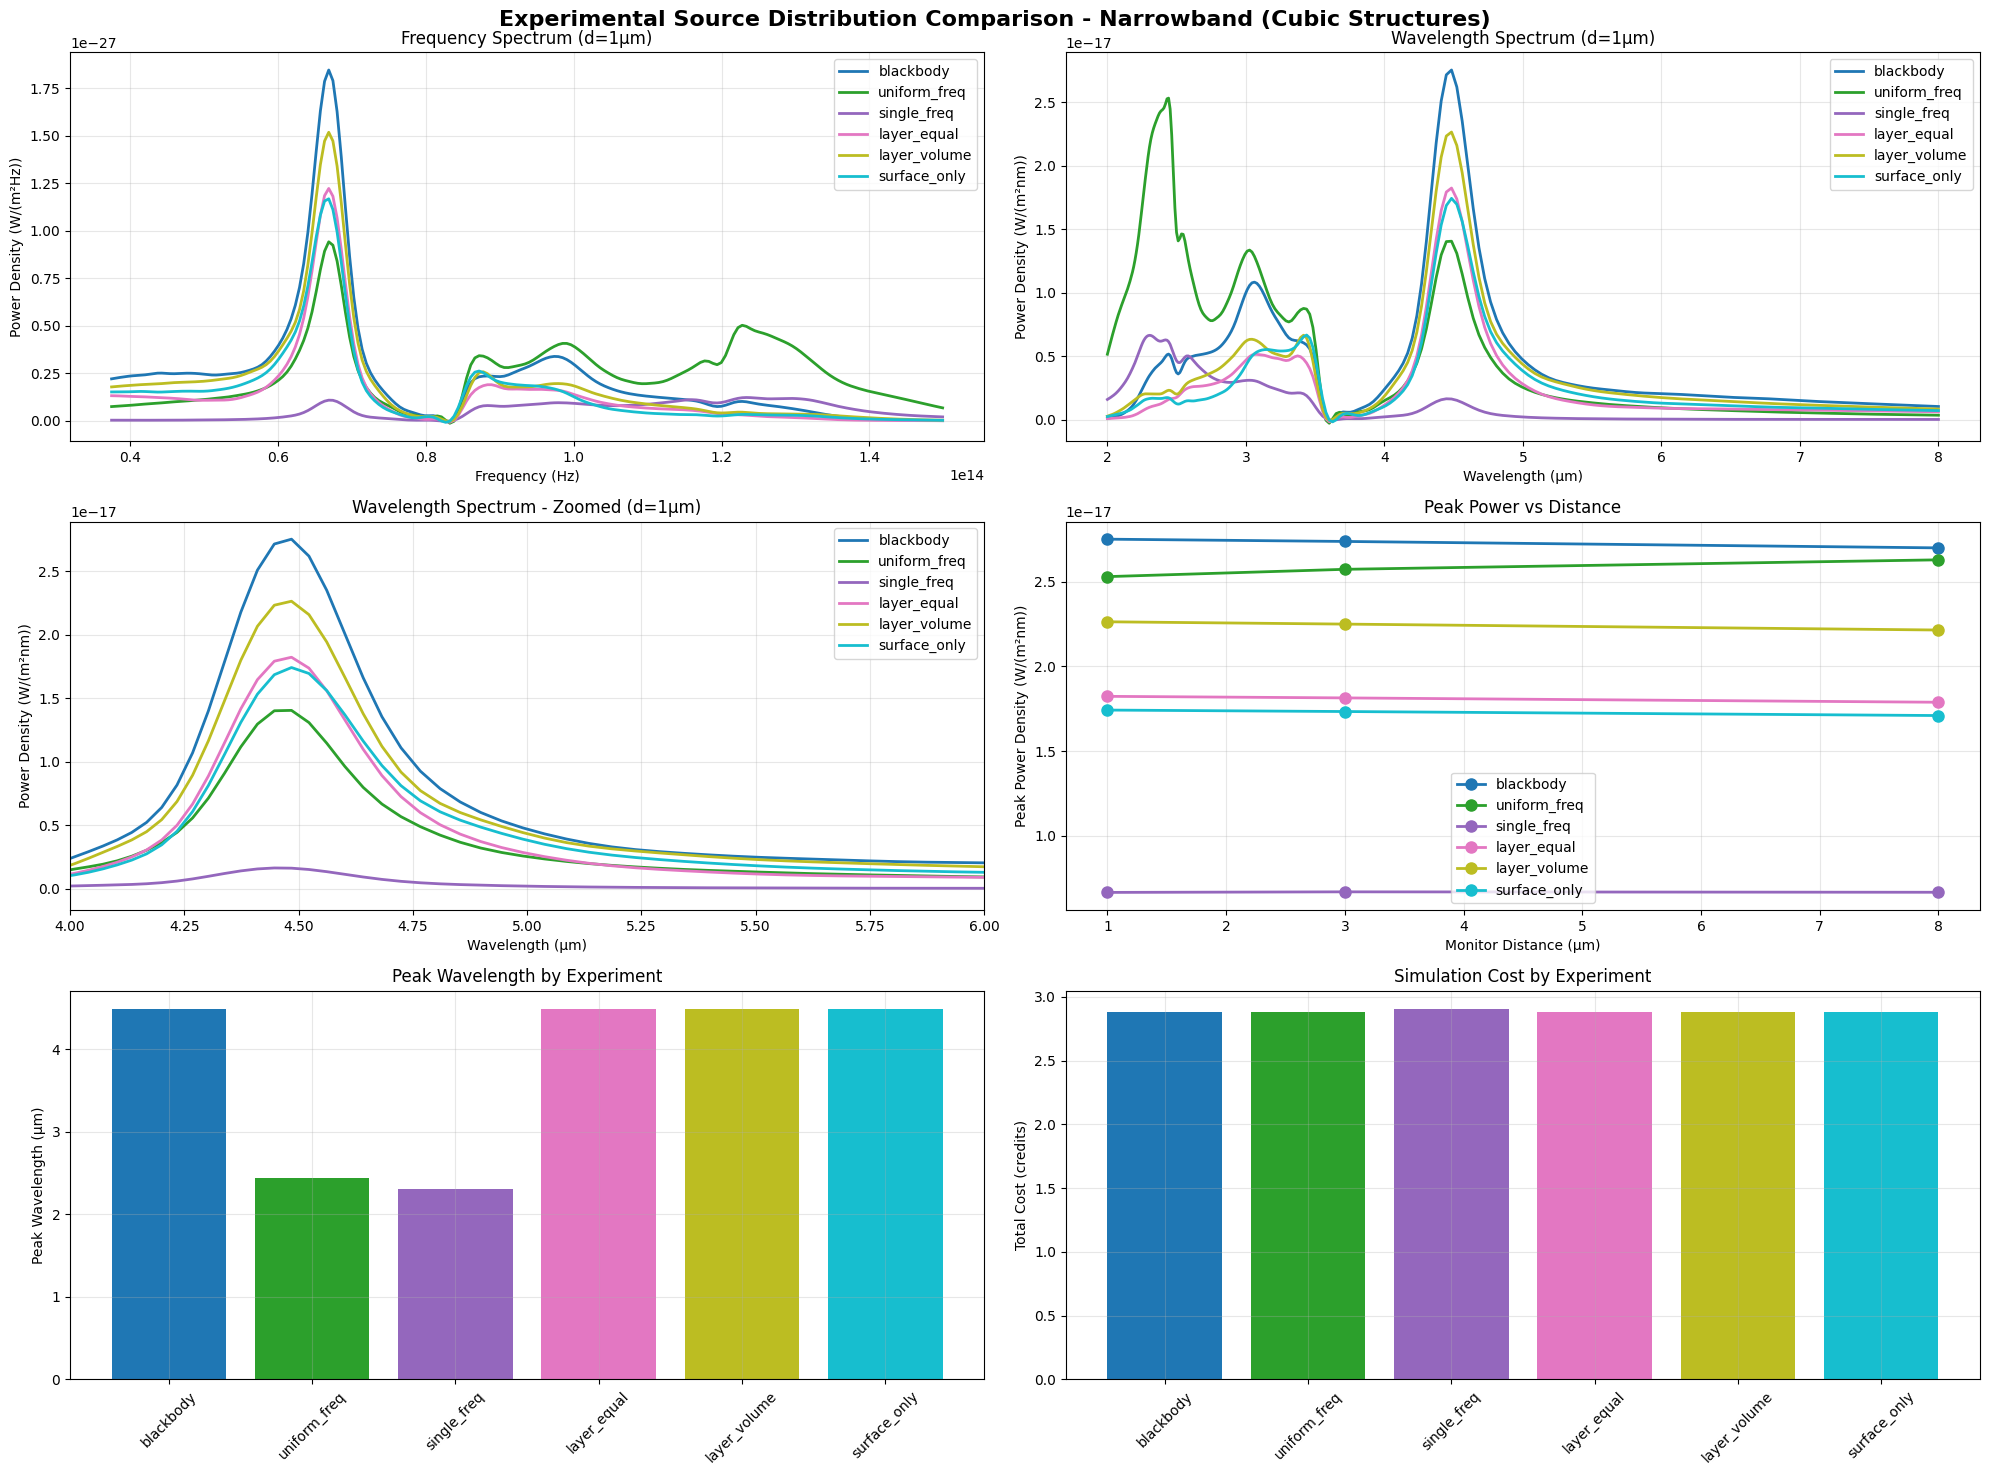


📊 CREATING INDIVIDUAL EXPERIMENT PLOTS
📈 Creating plots for blackbody...
   📊 blackbody plot saved as: narrowband_optimized_blackbody_results.png
   📊 blackbody plot saved as: narrowband_optimized_blackbody_results.png


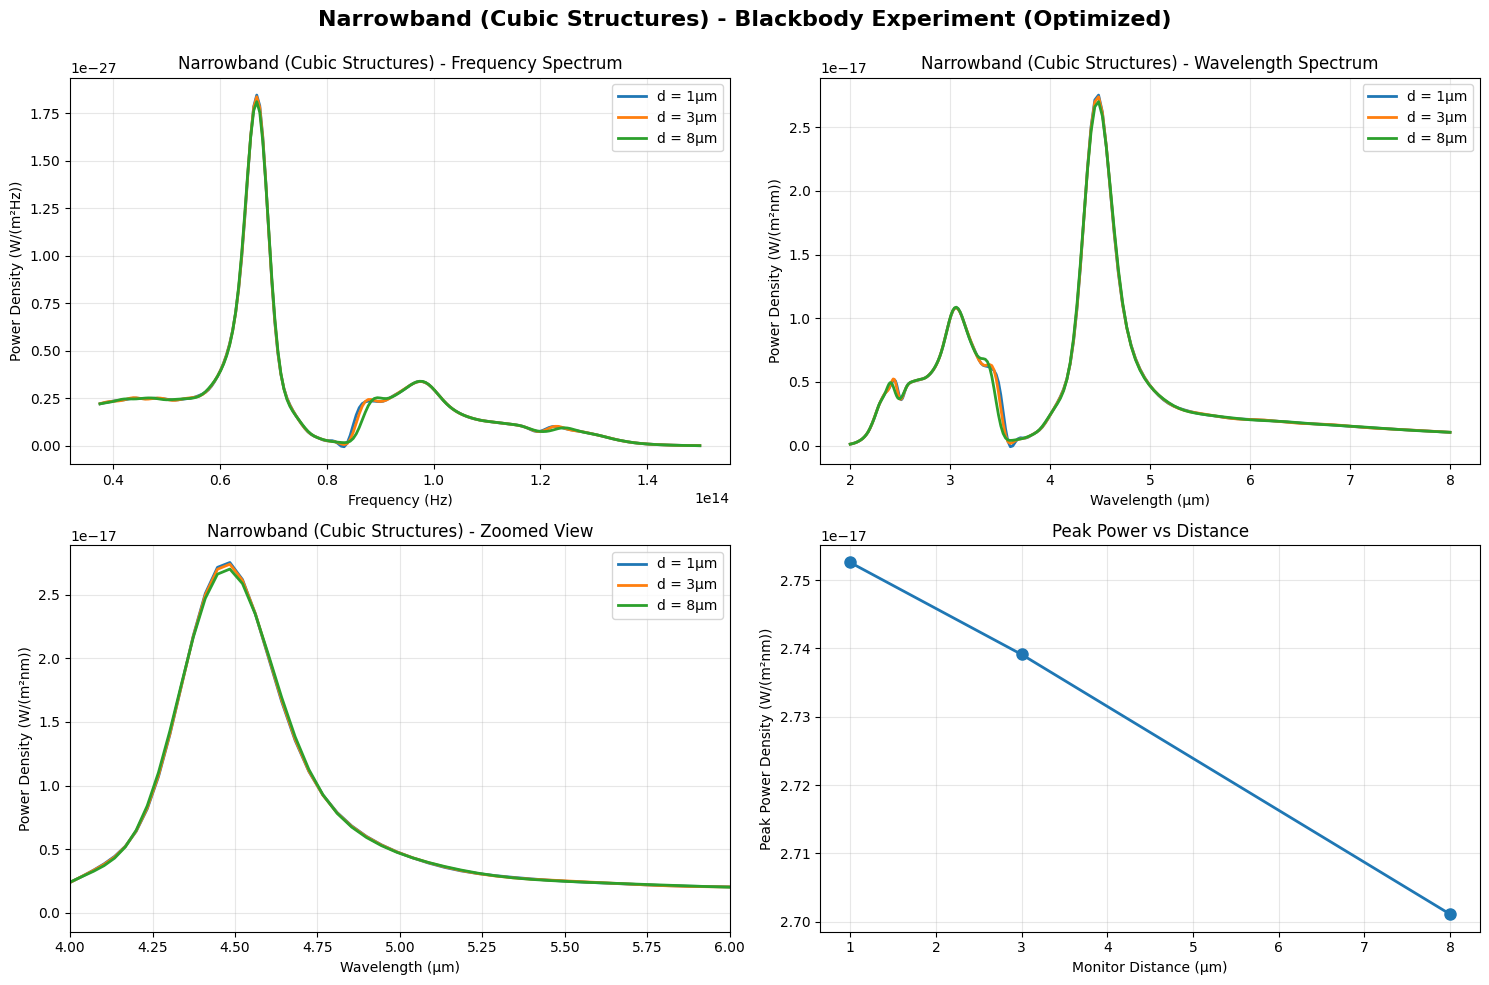

📈 Creating plots for uniform_freq...
   📊 uniform_freq plot saved as: narrowband_optimized_uniform_freq_results.png
   📊 uniform_freq plot saved as: narrowband_optimized_uniform_freq_results.png


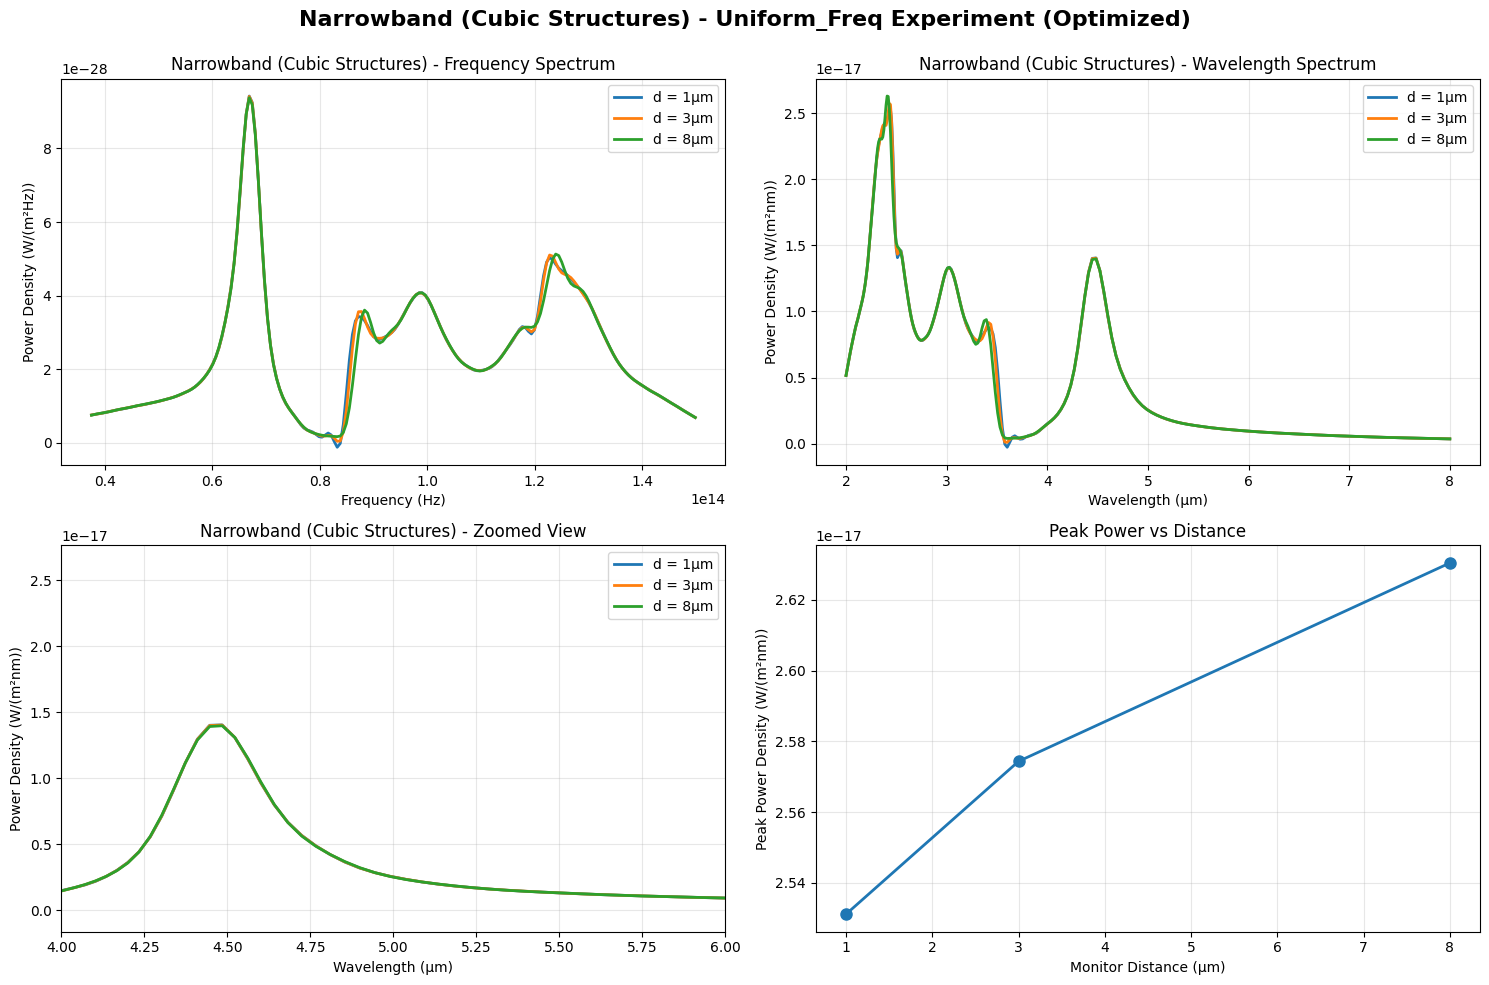

📈 Creating plots for single_freq...
   📊 single_freq plot saved as: narrowband_optimized_single_freq_results.png
   📊 single_freq plot saved as: narrowband_optimized_single_freq_results.png


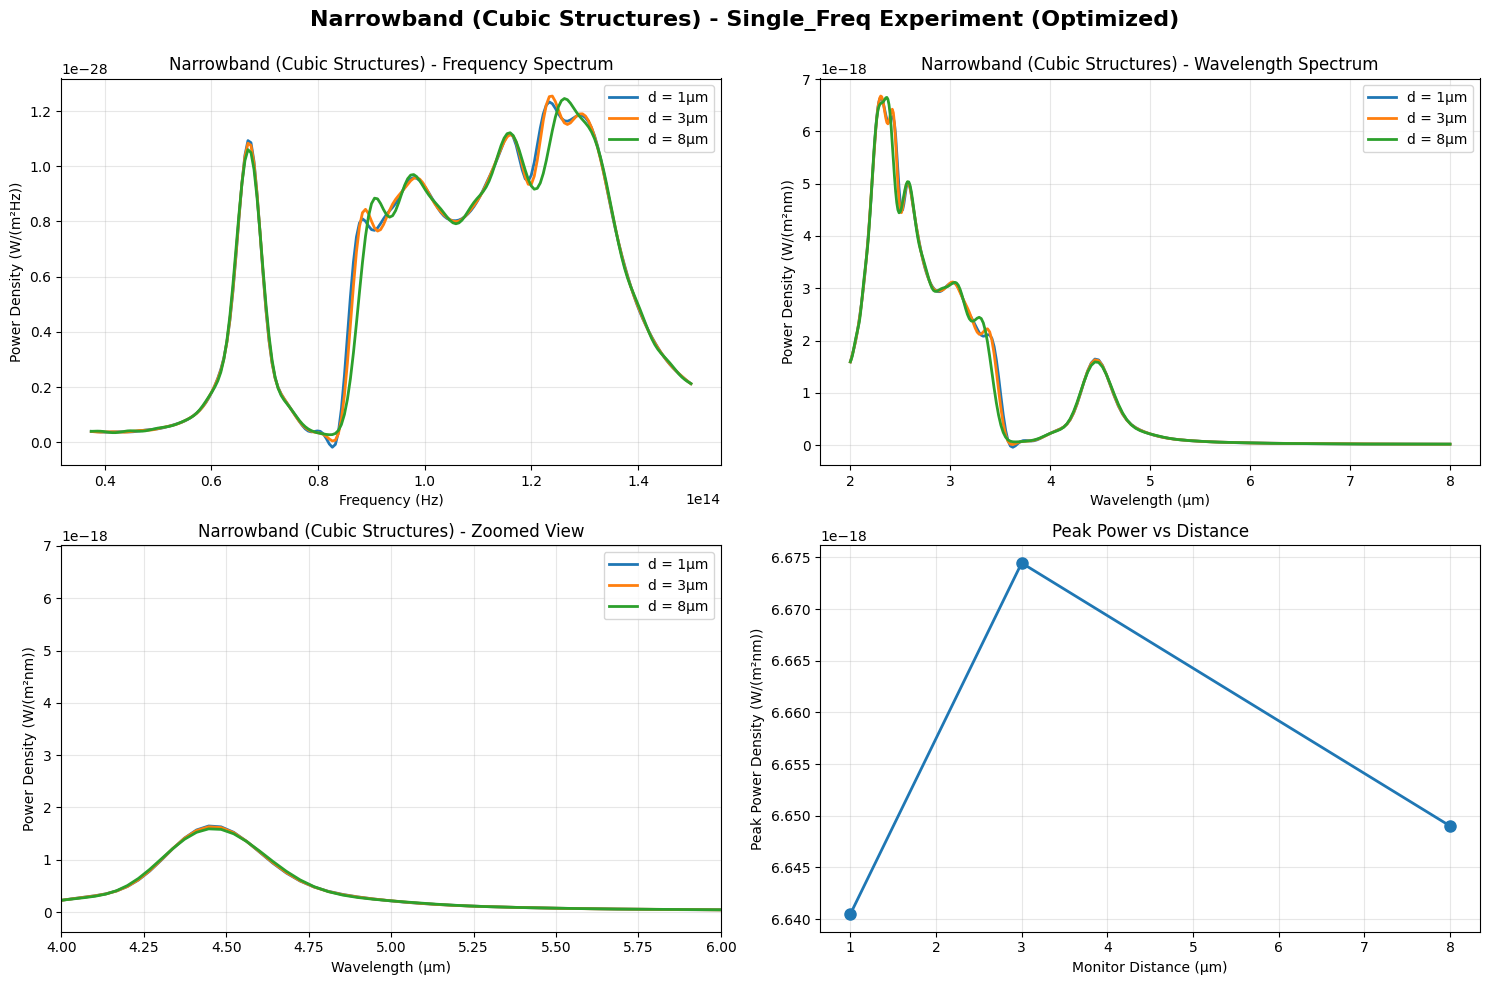

📈 Creating plots for layer_equal...
   📊 layer_equal plot saved as: narrowband_optimized_layer_equal_results.png
   📊 layer_equal plot saved as: narrowband_optimized_layer_equal_results.png


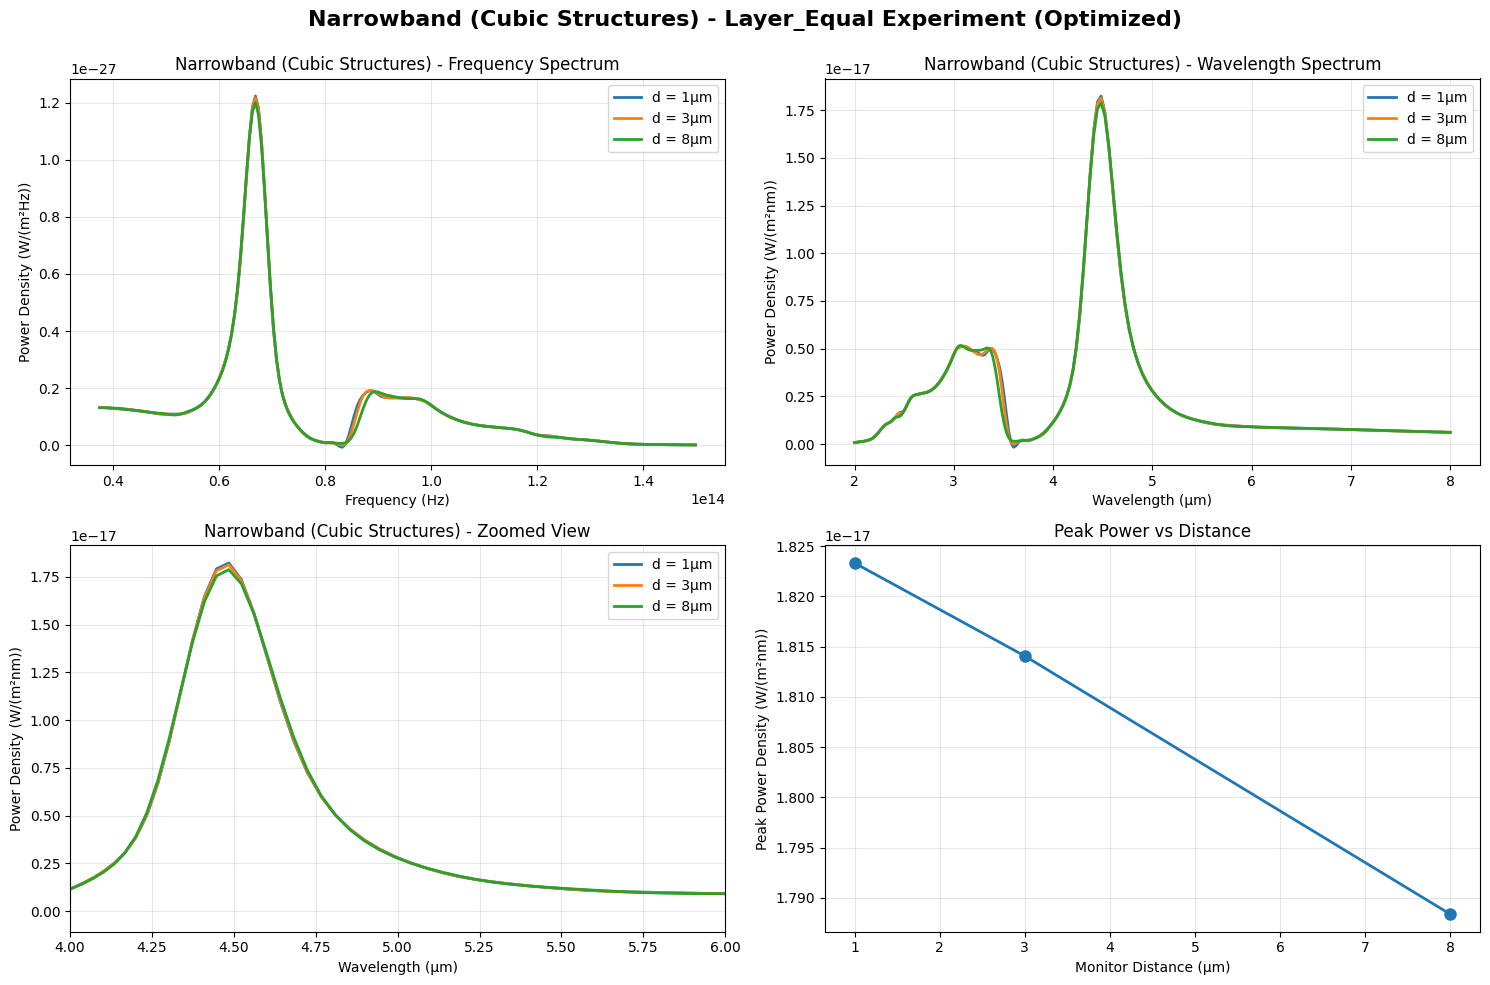

📈 Creating plots for layer_volume...
   📊 layer_volume plot saved as: narrowband_optimized_layer_volume_results.png
   📊 layer_volume plot saved as: narrowband_optimized_layer_volume_results.png


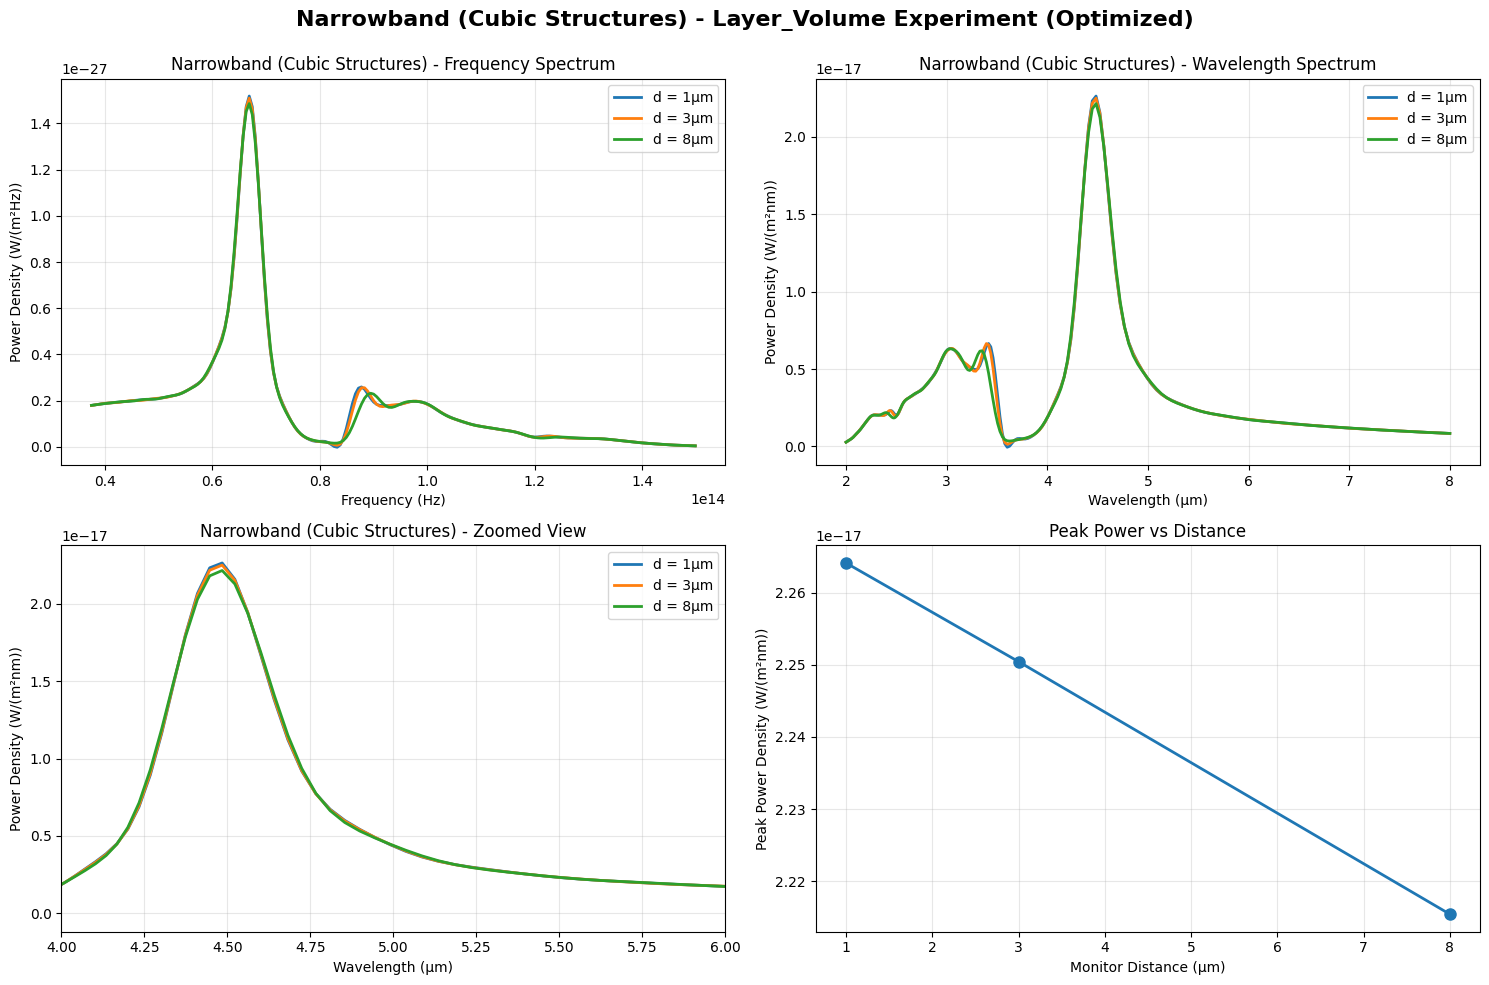

📈 Creating plots for surface_only...
   📊 surface_only plot saved as: narrowband_optimized_surface_only_results.png
   📊 surface_only plot saved as: narrowband_optimized_surface_only_results.png


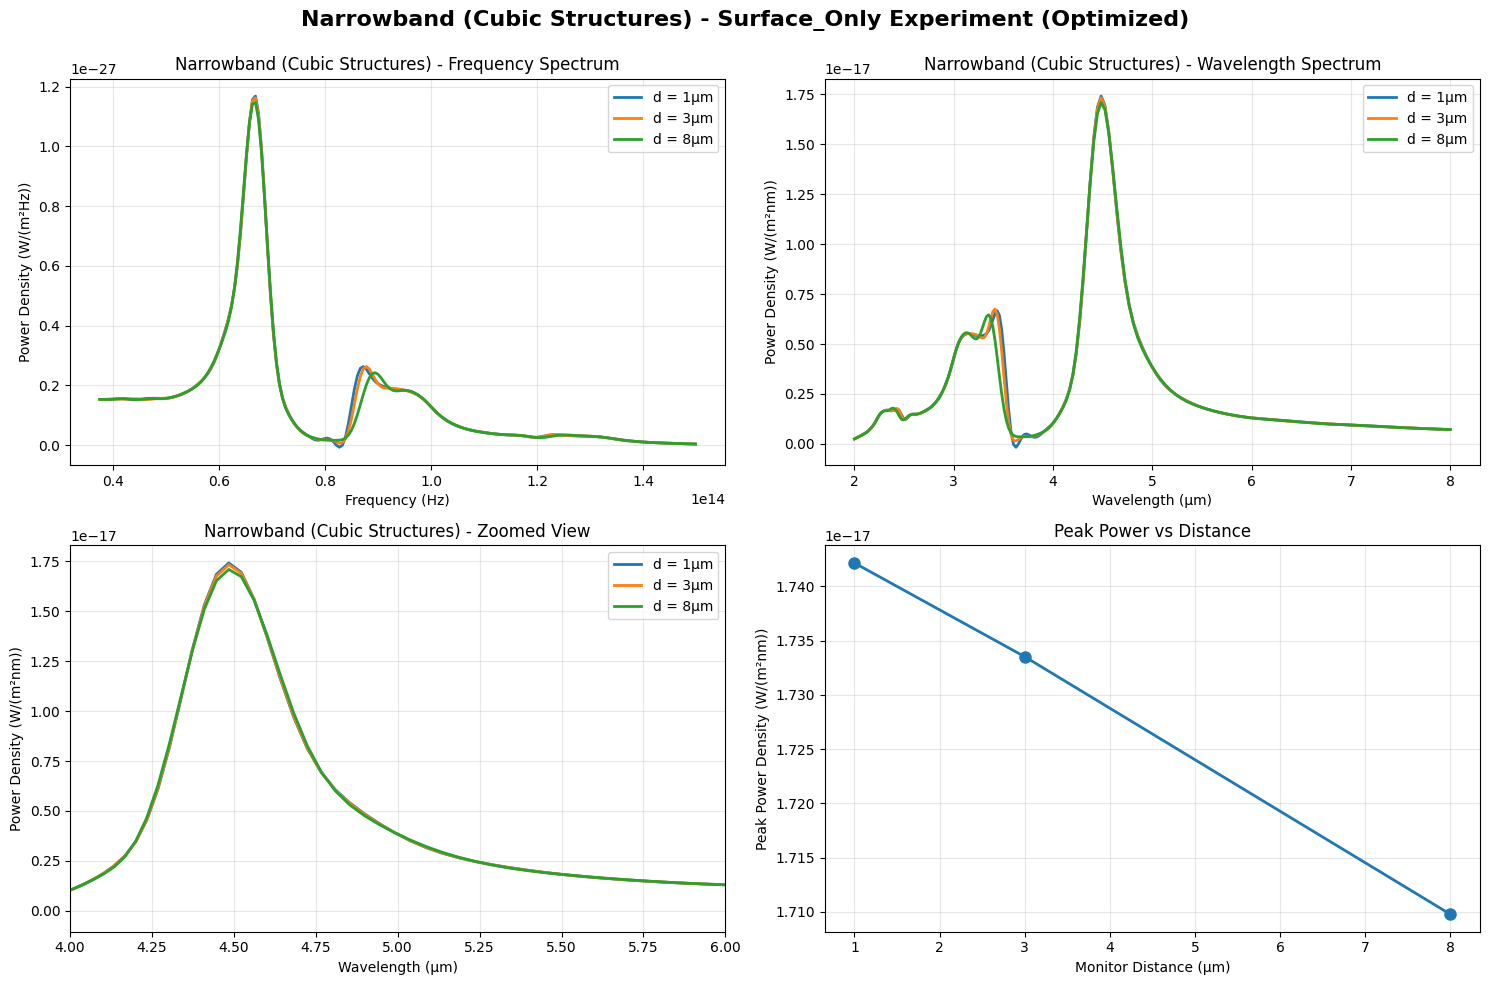


EXPERIMENTAL STUDY SUMMARY REPORT

Configuration:
   Geometry: Narrowband (Cubic Structures)
   Mode: Optimized
   Temperature: 650K
   Simulations per experiment: 10

Experimental Results:

Configuration:
   Geometry: Narrowband (Cubic Structures)
   Mode: Optimized
   Temperature: 650K
   Simulations per experiment: 10

Experimental Results:
   BLACKBODY:
      Cost: 2.88 credits
      Peak power: 2.75e-17 W/(m²nm)
      Peak wavelength: 4.48 μm
   UNIFORM_FREQ:
      Cost: 2.88 credits
      Peak power: 2.63e-17 W/(m²nm)
      Peak wavelength: 2.44 μm
   SINGLE_FREQ:
      Cost: 2.90 credits
      Peak power: 6.67e-18 W/(m²nm)
      Peak wavelength: 2.30 μm
   LAYER_EQUAL:
      Cost: 2.88 credits
      Peak power: 1.82e-17 W/(m²nm)
      Peak wavelength: 4.48 μm
   LAYER_VOLUME:
      Cost: 2.88 credits
      Peak power: 2.26e-17 W/(m²nm)
      Peak wavelength: 4.48 μm
   SURFACE_ONLY:
      Cost: 2.88 credits
      Peak power: 1.74e-17 W/(m²nm)
      Peak wavelength: 4.48 μm

Tot

In [16]:
experimental_data, comparison_filename, individual_filenames = (
    run_complete_experimental_study()
)

## Create and compare simulations

Generate both original and optimized versions for comparison:

In [17]:
print(f"Creating {geometry_name} simulations...\n")

# Create original simulation
print("Creating original simulation...")
sim_original = make_simulation_unified(T, GEOMETRY_TYPE, optimized=False)

# Create optimized simulation
print("\nCreating optimized simulation...")
sim_optimized = make_simulation_unified(T, GEOMETRY_TYPE, optimized=True)

print(f"\nDetailed comparison:")
print(f"{'Parameter':<25} {'Original':<15} {'Optimized':<15} {'Change':<10}")
print("-" * 70)

# Domain size comparison
orig_volume = sim_original.size[0] * sim_original.size[1] * sim_original.size[2]
opt_volume = sim_optimized.size[0] * sim_optimized.size[1] * sim_optimized.size[2]
volume_reduction = (1 - opt_volume / orig_volume) * 100

print(
    f"{'Domain volume (μm³)':<25} {orig_volume:<15.1f} {opt_volume:<15.1f} {-volume_reduction:<10.1f}%"
)

# Source count
source_reduction = (1 - len(sim_optimized.sources) / len(sim_original.sources)) * 100
print(
    f"{'Source count':<25} {len(sim_original.sources):<15} {len(sim_optimized.sources):<15} {-source_reduction:<10.1f}%"
)

# Grid resolution
orig_grid = sim_original.grid_spec.wavelength
opt_grid = sim_optimized.grid_spec.wavelength
grid_change = ((opt_grid - orig_grid) / orig_grid) * 100
print(
    f"{'Grid wavelength':<25} {orig_grid:<15.1f} {opt_grid:<15.1f} {grid_change:<10.1f}%"
)

# PML layers
orig_pml = sim_original.boundary_spec.z.plus.num_layers
opt_pml = sim_optimized.boundary_spec.z.plus.num_layers
pml_reduction = (1 - opt_pml / orig_pml) * 100
print(f"{'PML layers':<25} {orig_pml:<15} {opt_pml:<15} {-pml_reduction:<10.1f}%")

print(
    f"\nExpected cost reduction: ~{40 if USE_OPTIMIZATION else 0}-{50 if USE_OPTIMIZATION else 0}%"
)

Creating Narrowband (Cubic Structures) simulations...

Creating original simulation...
Narrowband (Cubic Structures) Original simulation created.
Sources: 1000, Grid: λ/0.20, PML: 30
Domain: 3.5×3.5×21.0 μm

Creating optimized simulation...
Narrowband (Cubic Structures) Original simulation created.
Sources: 1000, Grid: λ/0.20, PML: 30
Domain: 3.5×3.5×21.0 μm

Creating optimized simulation...
Narrowband (Cubic Structures) Optimized simulation created.
Sources: 700, Grid: λ/0.35, PML: 20
Domain: 3.5×3.5×17.0 μm

Detailed comparison:
Parameter                 Original        Optimized       Change    
----------------------------------------------------------------------
Domain volume (μm³)       257.2           208.2           -19.0     %
Source count              1000            700             -30.0     %
Grid wavelength           0.2             0.3             75.0      %
PML layers                30              20              -33.3     %

Expected cost reduction: ~40-50%
Narrowban

## Cost estimation

In [18]:
# Cost estimation
geometry_short = "NB" if GEOMETRY_TYPE == "cubic" else "WB"
job_sim_original = td.web.Job(
    simulation=sim_original, task_name=f"{geometry_short} Original"
)
job_sim_optimized = td.web.Job(
    simulation=sim_optimized, task_name=f"{geometry_short} Optimized"
)

estimated_cost_original = td.web.estimate_cost(job_sim_original.task_id)
estimated_cost_optimized = td.web.estimate_cost(job_sim_optimized.task_id)

cost_reduction = (1 - estimated_cost_optimized / estimated_cost_original) * 100

print(f"\nCost analysis:")
print(f"Original simulation: {estimated_cost_original:.2f} credits")
print(f"Optimized simulation: {estimated_cost_optimized:.2f} credits")
print(f"Cost reduction: {cost_reduction:.1f}%")

if cost_reduction >= 40:
    print("Target cost reduction achieved.")
elif cost_reduction >= 30:
    print("Moderate cost reduction achieved.")
else:
    print("Cost reduction below target; consider further optimization.")

15:07:37 BST Created task 'NB Original' with task_id                            
             'fdve-f158968e-99ac-44d7-82bc-4cd458b1b3dc' and task_type 'FDTD'.

             View task using web UI at                                          
             ]8;id=207520;https://tidy3d.simulation.cloud/workbench?taskId=fdve-f158968e-99ac-44d7-82bc-4cd458b1b3dc\'https://tidy3d.simulation.cloud/workbench?]8;;\]8;id=54324;https://tidy3d.simulation.cloud/workbench?taskId=fdve-f158968e-99ac-44d7-82bc-4cd458b1b3dc\taskId]8;;\]8;id=207520;https://tidy3d.simulation.cloud/workbench?taskId=fdve-f158968e-99ac-44d7-82bc-4cd458b1b3dc\=]8;;\]8;id=897635;https://tidy3d.simulation.cloud/workbench?taskId=fdve-f158968e-99ac-44d7-82bc-4cd458b1b3dc\fdve]8;;\]8;id=207520;https://tidy3d.simulation.cloud/workbench?taskId=fdve-f158968e-99ac-44d7-82bc-4cd458b1b3dc\-f158968e-99a]8;;\
             ]8;id=207520;https://tidy3d.simulation.cloud/workbench?taskId=fdve-f158968e-99ac-44d7-82bc-4cd458b1b3dc\c-44d7-82bc-4cd458b1b3dc']8;;\.

             Task folder: ]8;id=956367;https://tidy3d.simulation.cloud/folders/folder-3acfebee-3583-4698-8828-61a1d114e4a1\'default']8;;\.

Output()

15:07:40 BST Maximum FlexCredit cost: 1.267. Minimum cost depends on task       
             execution details. Use 'web.real_cost(task_id)' to get the billed  
             FlexCredit cost after a simulation run.

...

             Task folder: ]8;id=945156;https://tidy3d.simulation.cloud/folders/folder-3acfebee-3583-4698-8828-61a1d114e4a1\'default']8;;\.

Output()

15:07:44 BST Maximum FlexCredit cost: 0.288. Minimum cost depends on task       
             execution details. Use 'web.real_cost(task_id)' to get the billed  
             FlexCredit cost after a simulation run.

15:07:45 BST Maximum FlexCredit cost: 0.288. Minimum cost depends on task       
             execution details. Use 'web.real_cost(task_id)' to get the billed  
             FlexCredit cost after a simulation run.


Cost analysis:
Original simulation: 1.27 credits
Optimized simulation: 0.29 credits
Cost reduction: 77.3%
Target cost reduction achieved.


## Visualization comparison

In [19]:
print("Visualization comparison")
print("=" * 40)

print(f"Original {geometry_name.lower()} simulation:")
sim_original.plot_3d()

print(f"\nOptimized {geometry_name.lower()} simulation:")
sim_optimized.plot_3d()

print(f"\nKey differences:")
print("- Original: Large domain with structure centered")
print("- Optimized: Compact domain with structure near bottom")
print(f"- Geometry: {GEOMETRY_TYPE.title()} structures")
print("- Physics: Preserved (same relative positioning and thermal emission)")
print(f"- Cost: ~{cost_reduction:.0f}% reduction")

Visualization comparison
Original narrowband (cubic structures) simulation:



Optimized narrowband (cubic structures) simulation:



Key differences:
- Original: Large domain with structure centered
- Optimized: Compact domain with structure near bottom
- Geometry: Cubic structures
- Physics: Preserved (same relative positioning and thermal emission)
- Cost: ~77% reduction


## Batch simulation setup

Choose which simulation to run in batch mode:

In [20]:
# Choose simulation type for batch run
if USE_OPTIMIZATION:
    selected_sim = sim_optimized
    sim_type = "optimized"
    print(f"Using optimized {geometry_name.lower()} simulation")
else:
    selected_sim = sim_original
    sim_type = "original"
    print(f"Using original {geometry_name.lower()} simulation")

print(
    f"Estimated cost per simulation: {estimated_cost_optimized if USE_OPTIMIZATION else estimated_cost_original:.2f} credits"
)
print(
    f"Total batch cost ({num_sims} sims): {(estimated_cost_optimized if USE_OPTIMIZATION else estimated_cost_original) * num_sims:.2f} credits"
)

# Create batch
sims = {}
for i in range(1, num_sims + 1):
    sims[f"sim_{i}"] = make_simulation_unified(T, GEOMETRY_TYPE, USE_OPTIMIZATION)

print(f"\nBatch of {len(sims)} {sim_type} {geometry_name.lower()} simulations ready.")

Using optimized narrowband (cubic structures) simulation
Estimated cost per simulation: 0.29 credits
Total batch cost (10 sims): 2.88 credits
Narrowband (Cubic Structures) Optimized simulation created.
Sources: 700, Grid: λ/0.35, PML: 20
Domain: 3.5×3.5×17.0 μm
Narrowband (Cubic Structures) Optimized simulation created.
Sources: 700, Grid: λ/0.35, PML: 20
Domain: 3.5×3.5×17.0 μm
Narrowband (Cubic Structures) Optimized simulation created.
Sources: 700, Grid: λ/0.35, PML: 20
Domain: 3.5×3.5×17.0 μm
Narrowband (Cubic Structures) Optimized simulation created.
Sources: 700, Grid: λ/0.35, PML: 20
Domain: 3.5×3.5×17.0 μm
Narrowband (Cubic Structures) Optimized simulation created.
Sources: 700, Grid: λ/0.35, PML: 20
Domain: 3.5×3.5×17.0 μm
Narrowband (Cubic Structures) Optimized simulation created.
Sources: 700, Grid: λ/0.35, PML: 20
Domain: 3.5×3.5×17.0 μm
Narrowband (Cubic Structures) Optimized simulation created.
Sources: 700, Grid: λ/0.35, PML: 20
Domain: 3.5×3.5×17.0 μm
Narrowband (Cubic 

KeyboardInterrupt: 

## Run batch simulation

In [ ]:
# Build batch object
batch = td.web.Batch(simulations=sims, verbose=True)

# Run simulations
geometry_folder = "narrowband" if GEOMETRY_TYPE == "cubic" else "wideband"
opt_folder = "_optimized" if USE_OPTIMIZATION else ""
data_path = f"data_{geometry_folder}{opt_folder}/{T}K"

print(f"Running {len(sims)} simulations...")
print(f"Results will be saved to: {data_path}")

batch_results = batch.run(path_dir=data_path)

Running 10 simulations...
Results will be saved to: data_wideband_optimized/650K


Output()

KeyboardInterrupt: 

## Results analysis

In [ ]:
# Process results
data = []
for task_name, sim_data in batch_results.items():
    data.append(sim_data)

# Analyze flux data at different monitor distances
flux_data_distances = []
power_density_data_distances_f = []
power_density_data_distances_wvls = []

for distance in monitor_distances:
    flux = xr.concat([d[f"monitor_{distance}"].flux for d in data], dim="sim")
    flux_data_summed = np.array(flux.sum(dim="sim"))  # W

    # Power density calculations
    area = (Lx * 1e-6) * (Ly * 1e-6)  # m²
    power_dens_f = flux_data_summed / (area * monitor_freqs)  # W/(m²Hz)
    power_dens_wvl = flux_data_summed / (area * (monitor_wvls * 1e3))  # W/(m²nm)

    flux_data_distances.append(flux_data_summed)
    power_density_data_distances_f.append(power_dens_f)
    power_density_data_distances_wvls.append(power_dens_wvl)

print(f"Analysis complete for {len(data)} simulations")
print(f"Data processed for {len(monitor_distances)} monitor distances")

Analysis complete for 10 simulations
Data processed for 3 monitor distances


## Results visualization

Results saved as: wideband_optimized_results.png


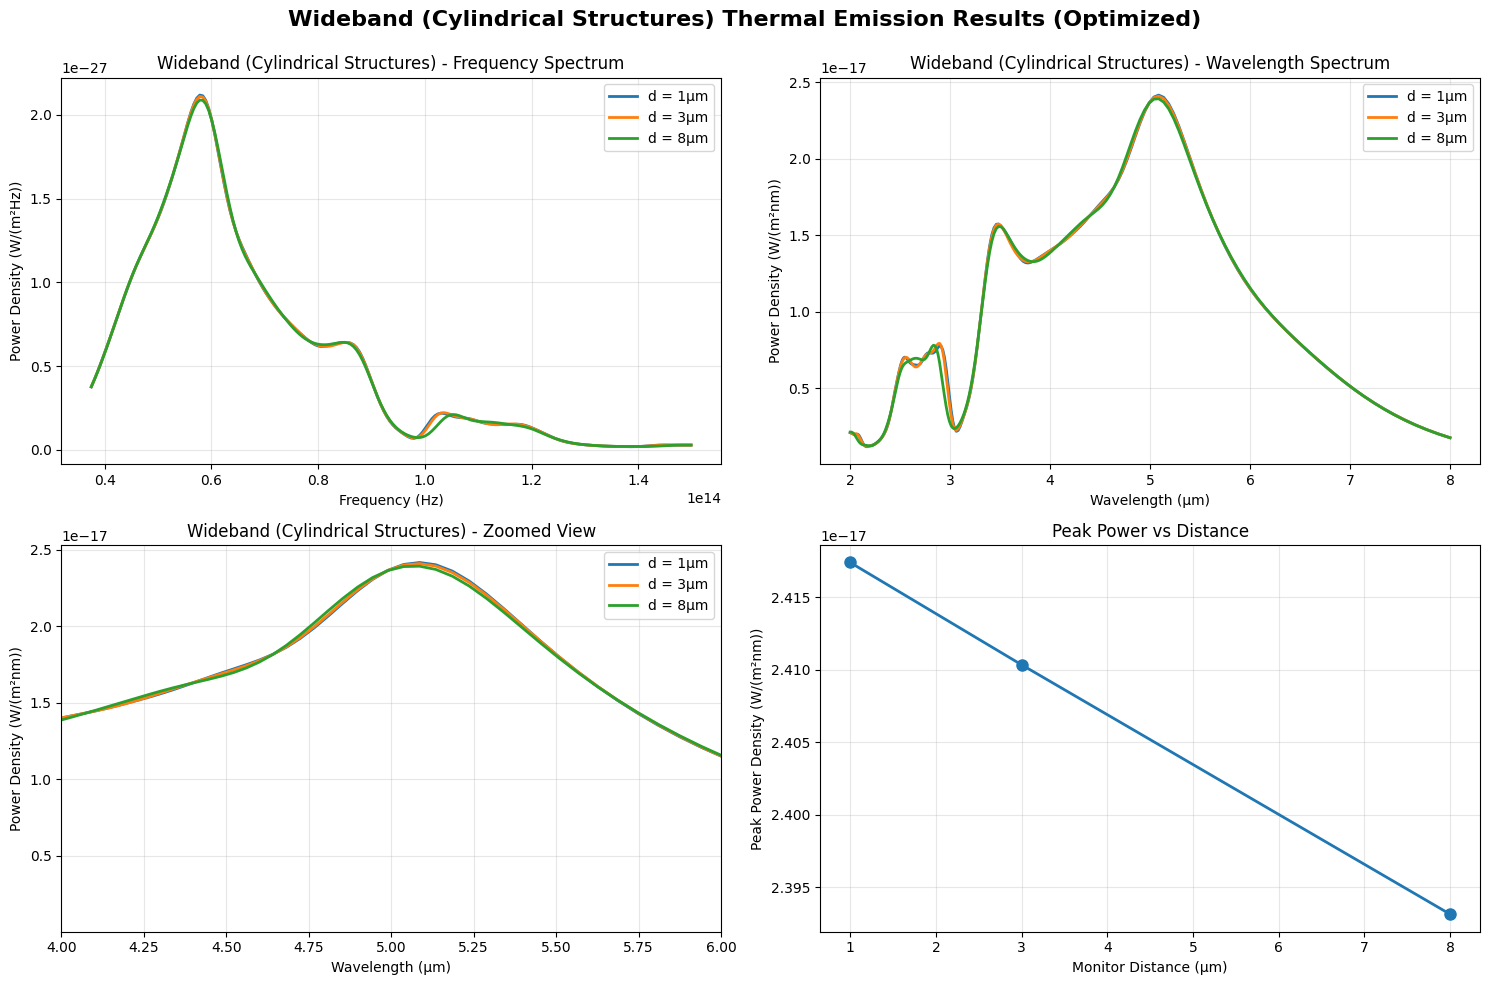

In [ ]:
# Create comprehensive results plots
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Frequency domain plot
ax1 = axes[0, 0]
for i, distance in enumerate(monitor_distances):
    ax1.plot(
        monitor_freqs,
        power_density_data_distances_f[i],
        label=f"d = {distance}μm",
        linewidth=2,
    )
ax1.set_xlabel("Frequency (Hz)")
ax1.set_ylabel("Power Density (W/(m²Hz))")
ax1.set_title(f"{geometry_name} - Frequency Spectrum")
ax1.legend()
ax1.grid(True, alpha=0.3)

# Wavelength domain plot
ax2 = axes[0, 1]
for i, distance in enumerate(monitor_distances):
    ax2.plot(
        monitor_wvls,
        power_density_data_distances_wvls[i],
        label=f"d = {distance}μm",
        linewidth=2,
    )
ax2.set_xlabel("Wavelength (μm)")
ax2.set_ylabel("Power Density (W/(m²nm))")
ax2.set_title(f"{geometry_name} - Wavelength Spectrum")
ax2.legend()
ax2.grid(True, alpha=0.3)

# Zoomed wavelength plot
ax3 = axes[1, 0]
for i, distance in enumerate(monitor_distances):
    ax3.plot(
        monitor_wvls,
        power_density_data_distances_wvls[i],
        label=f"d = {distance}μm",
        linewidth=2,
    )
ax3.set_xlabel("Wavelength (μm)")
ax3.set_ylabel("Power Density (W/(m²nm))")
ax3.set_title(f"{geometry_name} - Zoomed View")
ax3.set_xlim(4, 6)
ax3.legend()
ax3.grid(True, alpha=0.3)

# Summary plot
ax4 = axes[1, 1]
distances_array = np.array(monitor_distances)
peak_powers = [
    np.max(power_density_data_distances_wvls[i]) for i in range(len(monitor_distances))
]
ax4.plot(distances_array, peak_powers, "o-", linewidth=2, markersize=8)
ax4.set_xlabel("Monitor Distance (μm)")
ax4.set_ylabel("Peak Power Density (W/(m²nm))")
ax4.set_title("Peak Power vs Distance")
ax4.grid(True, alpha=0.3)

plt.suptitle(
    f"{geometry_name} Thermal Emission Results ({sim_type.title()})",
    fontsize=16,
    fontweight="bold",
)
plt.tight_layout()

# Save figure
filename = f"{geometry_folder}_{sim_type}_results.png"
plt.savefig(filename, dpi=300, bbox_inches="tight")
print(f"Results saved as: {filename}")
plt.show()

## Summary report

In [ ]:
print("\n" + "=" * 60)
print("SIMULATION SUMMARY REPORT")
print("=" * 60)

print(f"\nConfiguration:")
print(f"   Geometry: {geometry_name}")
print(f"   Mode: {sim_type.title()}")
print(f"   Temperature: {T}K")
print(f"   Simulations: {num_sims}")

print(f"\nOptimization results:")
if USE_OPTIMIZATION:
    print(f"   Domain reduction: {volume_reduction:.1f}%")
    print(f"   Source reduction: {source_reduction:.1f}%")
    print(f"   PML reduction: {pml_reduction:.1f}%")
    print(f"   Cost reduction: {cost_reduction:.1f}%")
else:
    print("   Original configuration used")
    print("   No optimizations applied")

print(f"\nCost analysis:")
cost_per_sim = estimated_cost_optimized if USE_OPTIMIZATION else estimated_cost_original
total_cost = cost_per_sim * num_sims
print(f"   Per simulation: {cost_per_sim:.2f} credits")
print(f"   Total batch: {total_cost:.2f} credits")

print(f"\nPhysics results:")
max_power = max([np.max(pd) for pd in power_density_data_distances_wvls])
min_distance_power = power_density_data_distances_wvls[0]  # 1μm distance
peak_wavelength = monitor_wvls[np.argmax(min_distance_power)]
print(f"   Peak power density: {max_power:.2e} W/(m²nm)")
print(f"   Peak wavelength: {peak_wavelength:.2f} μm")
print(f"   Emission range: {min(monitor_wvls):.1f} - {max(monitor_wvls):.1f} μm")

print(f"\nData saved:")
print(f"   Directory: {data_path}")
print(f"   Results plot: {filename}")

print(f"\nSimulation completed successfully.")
print("=" * 60)


SIMULATION SUMMARY REPORT

Configuration:
   Geometry: Wideband (Cylindrical Structures)
   Mode: Optimized
   Temperature: 650K
   Simulations: 10

Optimization results:
   Domain reduction: 19.0%
   Source reduction: 30.0%
   PML reduction: 33.3%
   Cost reduction: 76.7%

Cost analysis:
   Per simulation: 0.22 credits
   Total batch: 2.16 credits

Physics results:
   Peak power density: 2.42e-17 W/(m²nm)
   Peak wavelength: 5.09 μm
   Emission range: 2.0 - 8.0 μm

Data saved:
   Directory: data_wideband_optimized/650K
   Results plot: wideband_optimized_results.png

Simulation completed successfully.
